In [1]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import matplotlib.mlab as mlab
from sklearn.ensemble import IsolationForest
import os
import time
from copy import deepcopy
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from collections import defaultdict
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest
from baskervillehall.baskervillehall_isolation_forest import ModelType
from baskervillehall.feature_extractor import FeatureExtractor

plt.rcParams["figure.figsize"] = (15,5)

2025-06-10 08:54:08.721227: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-10 08:54:08.836008: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-10 08:54:08.933929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749545649.059439      86 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749545649.095883      86 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749545649.345817      86 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
import logging
import sys
logger = logging.getLogger('pca')
logger.addHandler(logging.StreamHandler())
logger.addHandler(logging.StreamHandler(sys.stdout))
logger.setLevel('DEBUG')
os.environ['S3_ACCESS'] = 'c490f17bdb784fa08f4d11836ee18e48'
os.environ['S3_SECRET'] = 'e4b65e27b3734d0d96ce6038586ef43f'
os.environ['S3_ENDPOINT'] = 's3.gra.cloud.ovh.net'
os.environ['S3_REGION'] = 'GRA'

In [3]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
# kafka_url = ['kafkab-0.kafkab-headless.default.svc.cluster.local:9093','kafkab-1.kafkab-headless.default.svc.cluster.local:9093','kafka9-b.kafkab-headless.default.svc.cluster.local:9093']

In [4]:
partitions = {
    'vytoki.net': 0,
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'btselem.org': 0,
    'verafiles.org': 1,
    'telegraf.in.ua': 2,
    'gubernia.com': 1,
    'informator.ua': 0,
    'culturesofresistance.org': 2,
    'zmina.info': 1,
    'memex.craphound.com': 2,
    'greencubator.info': 0
}

In [5]:
# host = 'kl.informator.ua'
# host = 'verafiles.org'
# host = 'zhitomir.info'
# host = 'deflect.ca'
# host = 'btselem.org'
# host = 'nswp.org'
# host = 'indymedia.nl'
# host = 'urban-pushkino.ru'
# host = 'verafiles.org'
# host = 'zmina.info'
# host = 'memex.craphound.com'
host = 'greencubator.info'

dataset_size = 1000
datetime_format = '%Y-%m-%d %H:%M:%S'
# features = [
#             'request_rate',
#             'post_rate',
#             'request_interval_average',
#             'request_interval_std',
#             'response4xx_to_request_ratio',
#             'response5xx_to_request_ratio',
#             'top_page_to_request_ratio',
#             'unique_path_rate',
#             'unique_path_to_request_ratio',
#             'unique_query_rate',
#             'unique_query_to_unique_path_ratio',
#             'image_to_html_ratio',
#             'js_to_html_ratio',
#             'css_to_html_ratio',
#             'path_depth_average',
#             'path_depth_std',
#             'payload_size_log_average',
#             'entropy',
#             'num_requests',
#             'duration',
#             'edge_entropy',
#             'static_ratio',
#             'ua_entropy',
#             # 'pca'
# ]

In [6]:
features = [
    'request_rate',
    'post_rate',
    'request_interval_average',
    'request_interval_std',
    'response4xx_to_request_ratio',
    'top_page_to_request_ratio',
    'unique_path_rate',
    'unique_path_to_request_ratio',
    'unique_query_rate',
    'unique_query_to_unique_path_ratio',
    'image_to_html_ratio',
    'js_to_html_ratio',
    'css_to_html_ratio',
    'path_depth_average',
    'path_depth_std',
    'payload_size_log_average',
    'entropy',
    'edge_count',
    'static_ratio',
    'ua_count',
    'api_ratio',
    'num_ciphers',
    'hour_bucket',
    'odd_hour'
]
categorical_features=[
            'country',
            'primary_session',
            'bad_bot',
            'human',
            'cipher',
            'valid_browser_ciphers',
            'weak_cipher',
            'headless_ua',
            'bot_ua',
            'ai_bot_ua',
            'verified_bot',
            'datacenter_asn',
            'short_ua',
            'asset_only'
]

In [7]:
topic = 'BASKERVILLEHALL_4'
# topic = 'logstash_deflect.log'
# topic = 'STATS_WEBLOGS_5M'
# topic = 'anton31'

In [8]:
import math
from collections import defaultdict

class EntropyCalculator:
    def __init__(self):
        # Structure: {host: {value: count}}
        self.value_counts = defaultdict(lambda: defaultdict(int))
        self.total_counts = defaultdict(int)  # {host: total values seen}

    def process(self, host, value):
        """Update count of a given value seen for a specific host."""
        self.value_counts[host][value] += 1
        self.total_counts[host] += 1

    def get_entropy(self, host, value):
        """Return entropy score for a value within a given host's distribution.
           Higher = rarer = higher entropy (0.0 to 1.0).
        """
        total = self.total_counts.get(host, 0)
        if total == 0:
            return 1.0  # First time we've seen anything for this host

        freq = self.value_counts[host].get(value, 0)
        probability = freq / total
        return round(1.0 - probability, 5)  # Higher = more unique

    def get_distribution_entropy(self, host):
        """Returns Shannon entropy across all values for a host."""
        total = self.total_counts.get(host, 0)
        if total == 0:
            return 0.0

        entropy = 0.0
        for freq in self.value_counts[host].values():
            p = freq / total
            entropy -= p * math.log2(p)
        return round(entropy, 5)


In [10]:
def read_sessions(host, size=1000, model_type=None):
    consumer = KafkaConsumer(
        bootstrap_servers=kafka_url,
        group_id='anton11'
    )
    
    num = 0
    partition = partitions[host]
    
    print(f'Reading from kafka. Host = {host} ... partition = {partition}')
    time_now = int(time.time())
    sessions = []

    consumer.assign([TopicPartition(topic, partition)])
    consumer.seek_to_beginning()
    complete = False
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=100)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes} minutes. Topic offset is too close to the current times...')
                    complete = True
                    break
                
                if message.value is None :
                    continue
                if message.key is None:
                    continue
                if message.key.decode("utf-8") != host:
                    continue

                session = json.loads(message.value.decode("utf-8"))       

                if session['ip'] == '62.244.50.139':
                    print (session);
                    
                if model_type == ModelType.HUMAN:
                    if not session['human']:
                        continue
                elif model_type == ModelType.BOT:
                    if session['human']:
                        continue
                        
                if len(sessions) == 0:
                    print(f'First session start = {session["start"]} end = {session["end"]}')

                sessions.append(session)
                if num == size:
                    complete = True
                    break
                num += 1
                if num % 100 == 0:
                    print(f'{num} sessions read', session['end'], message.timestamp)

            
    return sessions

In [11]:
model_type = ModelType.HUMAN
sessions = read_sessions(host, 10000, model_type=model_type)
print('Done.')

Reading from kafka. Host = greencubator.info ... partition = 0
First session start = 2025-06-09 23:22:54 end = 2025-06-09 23:23:06
1.9993666648864745 minutes. Topic offset is too close to the current times...
Done.


In [40]:
entropy_asn = EntropyCalculator()
for s in sessions:
    entropy_asn.process(host, s['fingerprints'])

In [41]:
import matplotlib.pyplot as plt

def plot_entropy_distribution(calculator, host, top_n=10):
    """
    Plots the top-N most frequent values for a given host.
    """
    value_map = calculator.value_counts.get(host)
    if not value_map:
        print(f"No data for host: {host}")
        return

    # Filter values with count > 0 and sort them
    sorted_items = sorted(
        [(str(k), v) for k, v in value_map.items() if v > 0],
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    if not sorted_items:
        print(f"No values with non-zero count for host: {host}")
        return

    values, counts = zip(*sorted_items)

    plt.figure(figsize=(10, 5))
    plt.bar(values, counts, color='mediumseagreen')
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Top {top_n} Value Frequencies for Host: {host}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


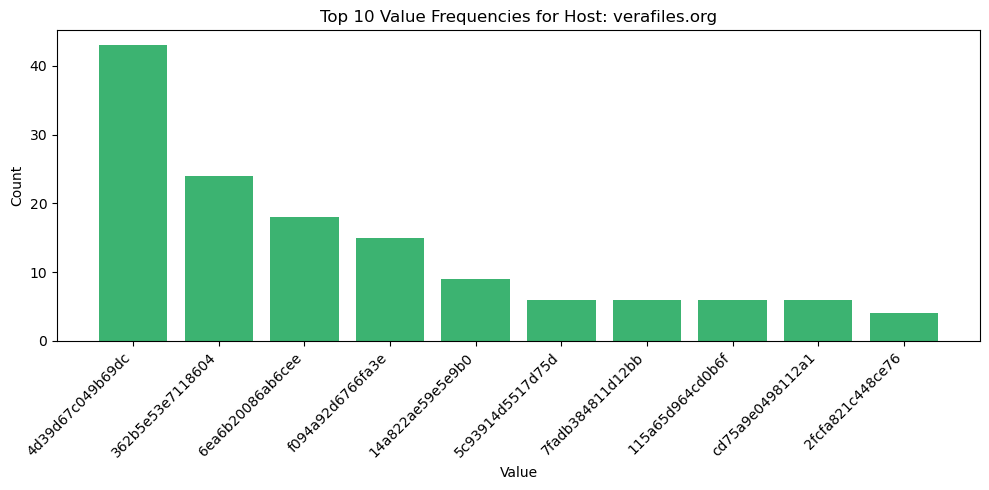

In [42]:
plot_entropy_distribution(entropy_asn, host)

In [12]:
if model_type == ModelType.GENERIC:
    if 'human' not in categorical_features:
        categorical_features.append('human')
    if 'bad_bot' not in categorical_features:
        categorical_features.append('bad_bot')

In [13]:
model = BaskervillehallIsolationForest(
    features=features,
    categorical_features=categorical_features,
    n_estimators=2000,
    max_samples=1024,
    contamination=0.03,
    max_features=0.8,
    bootstrap=True,
    n_jobs=1,
    random_state=777,
    logger=logger
)

In [14]:
model.fit(sessions)

/opt/conda/lib/python3.11/site-packages/sklearn/ensemble/_iforest.py:307: UserWarning: max_samples (1024) is greater than the total number of samples (600). max_samples will be set to n_samples for estimation.
  warn(


## Model IO

In [15]:
# import logging
# import pickle
# from baskervillehall.model_io import ModelIO
# s3_connection = {
#     's3_access':os.environ['S3_ACCESS'],
#     's3_secret':os.environ['S3_SECRET'],
#     's3_endpoint': os.environ['S3_ENDPOINT'],
#     's3_region':os.environ['S3_REGION']
# }
# model_io = ModelIO(**s3_connection, logger=logger)
# model = model_io.load(path='anton/baslervillehall/models54', host=host, 
#                       model_type=ModelType.HUMAN)

In [16]:
model

In [17]:
train_scores, train_shapley = model.transform(sessions)

In [18]:
def challenge_rate(scores):
    return len(scores[scores < 0]) / len(scores)

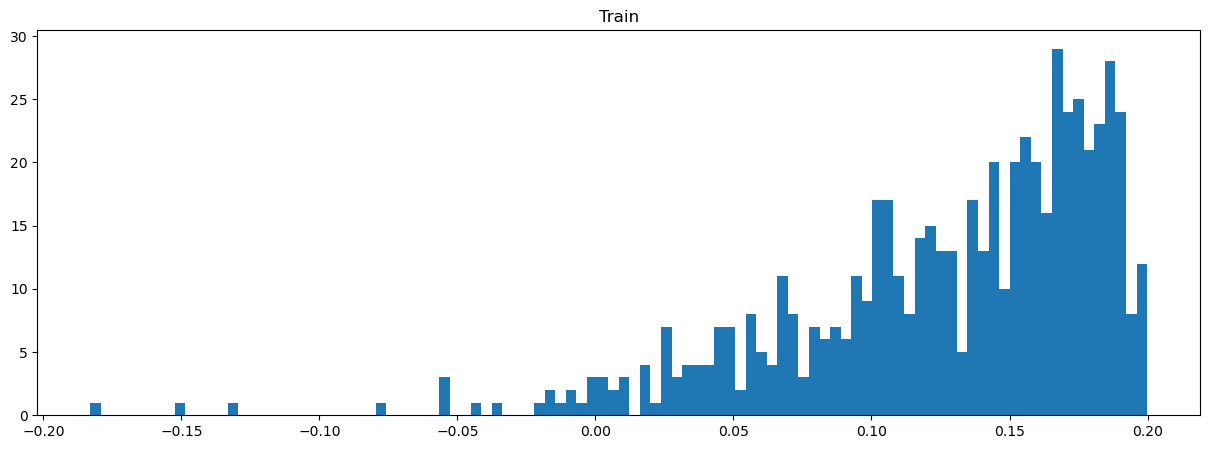

Challenge rate = 0.03


In [19]:
a = np.hstack(train_scores)
_ = plt.hist(a, bins=100)  
plt.title('Train')
plt.show()
print(f'Challenge rate = {challenge_rate(train_scores)}')

In [20]:
fe = FeatureExtractor(features=features, categorical_features=categorical_features)
Z_train = np.array(fe.fit_transform(sessions))

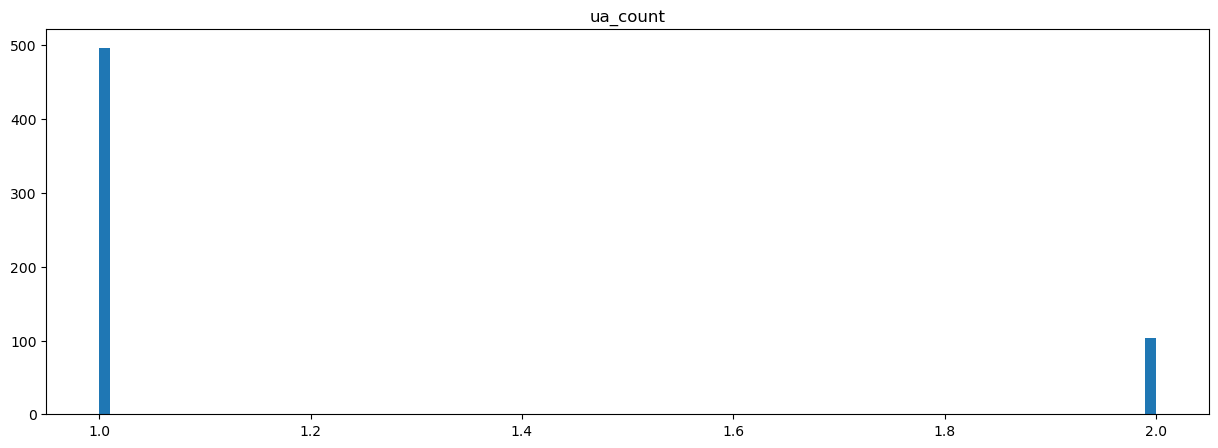

In [21]:
ua_count = []
for i in range(len(sessions)):
    s = sessions[i]
    ua_count.append(len(set([r['ua'] for r in s['requests']])))
a = np.hstack(ua_count)
_ = plt.hist(a, bins=100)  
plt.title('ua_count')
plt.show()


In [22]:
def get_shapley_features(model, shap_value):
    shapley_features = []
    for k in range(len(shap_value.values)):
        sv = shap_value.values[k]
        feature = model.get_all_features()[k]
        if feature == 'api_ratio':
            api_ratio = round(shap_value.data[k], 2)
        if sv < 0:
            shapley_features.append((feature, sv, shap_value.data[k]))
    shapley_features = sorted(shapley_features, key=lambda x: x[1])
    return shapley_features


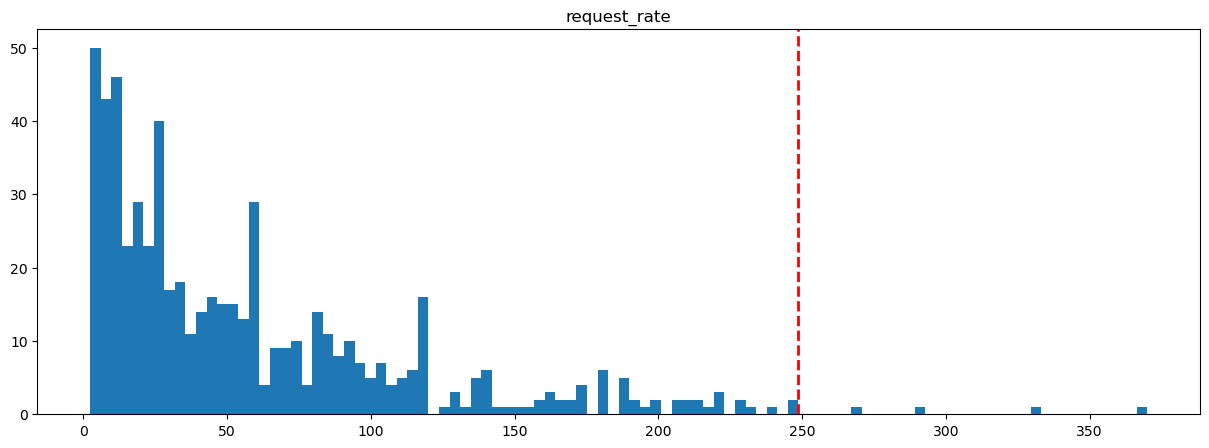

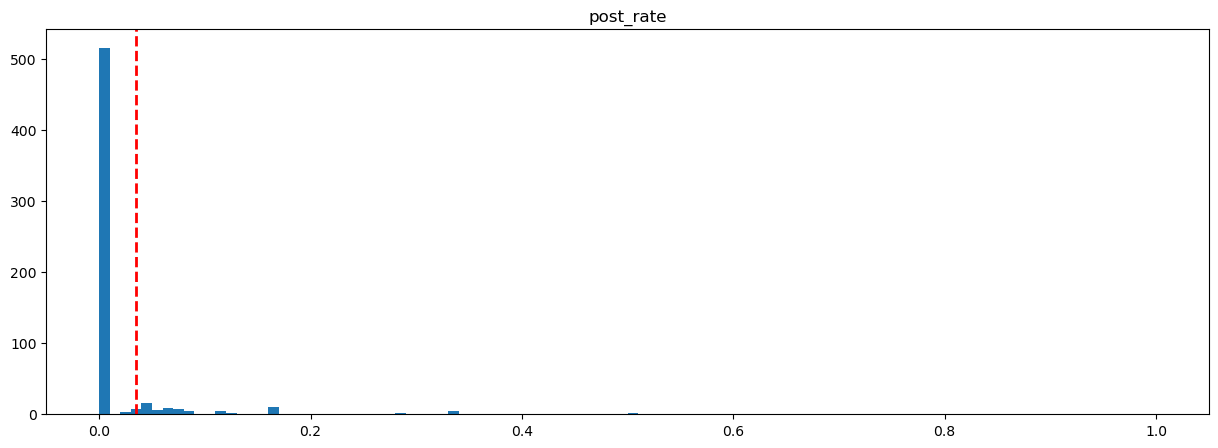

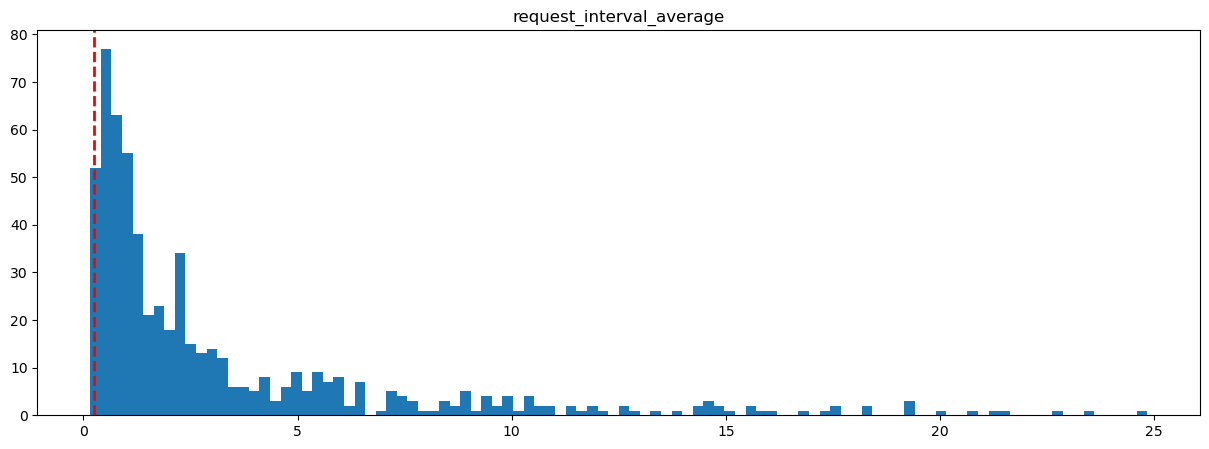

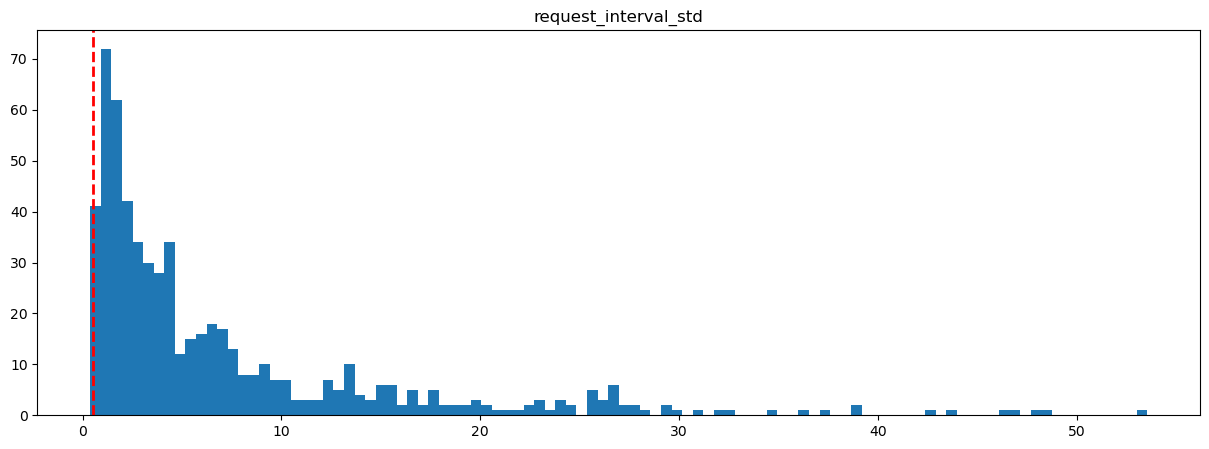

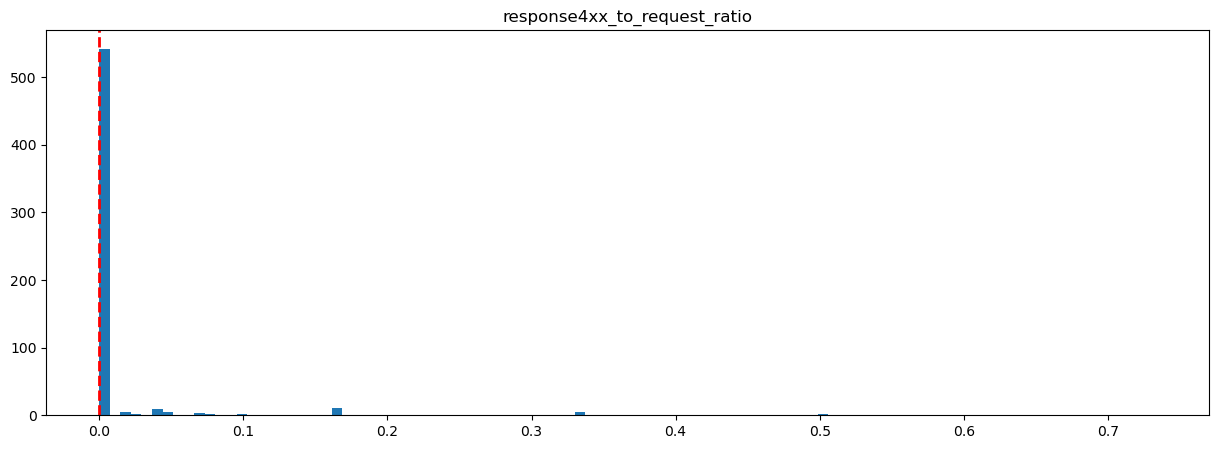

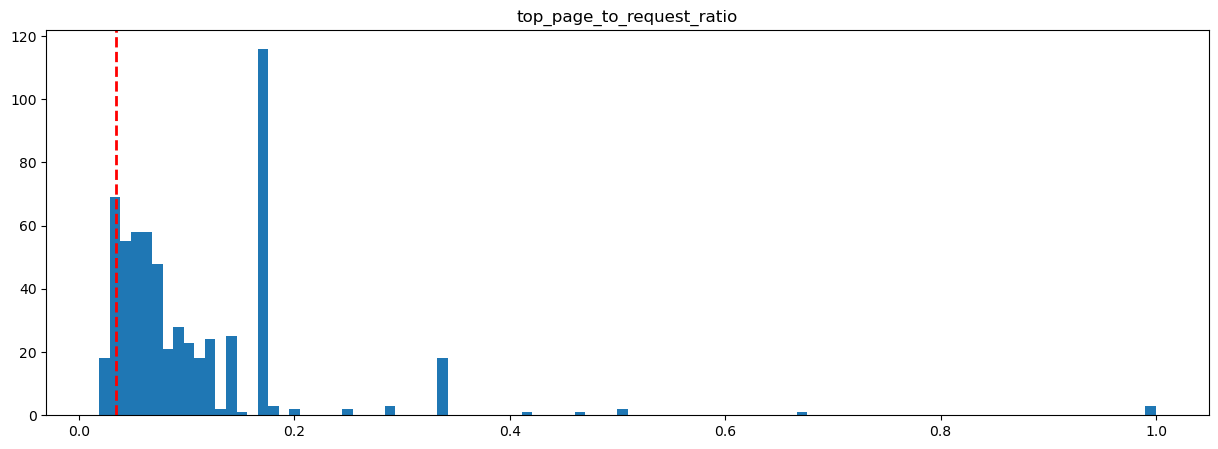

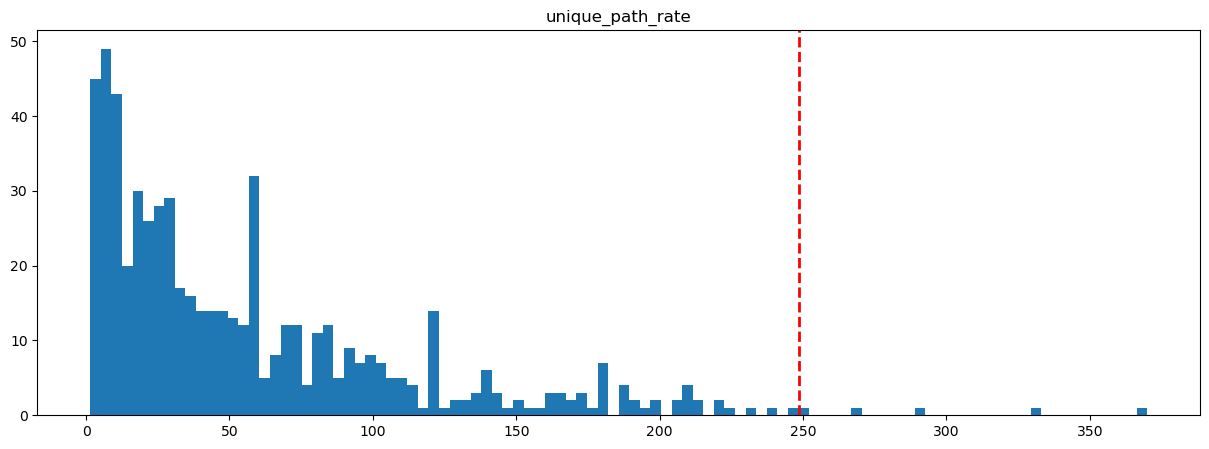

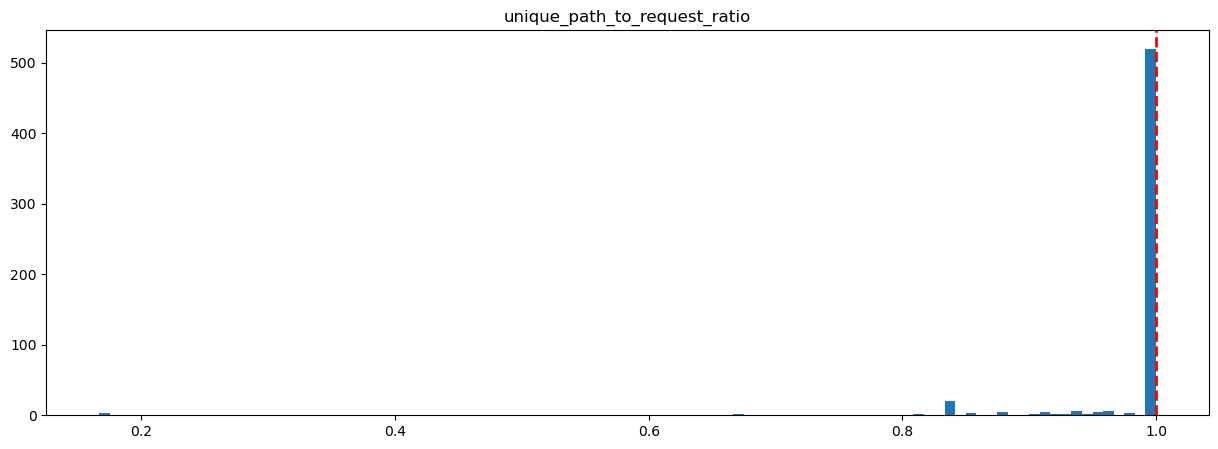

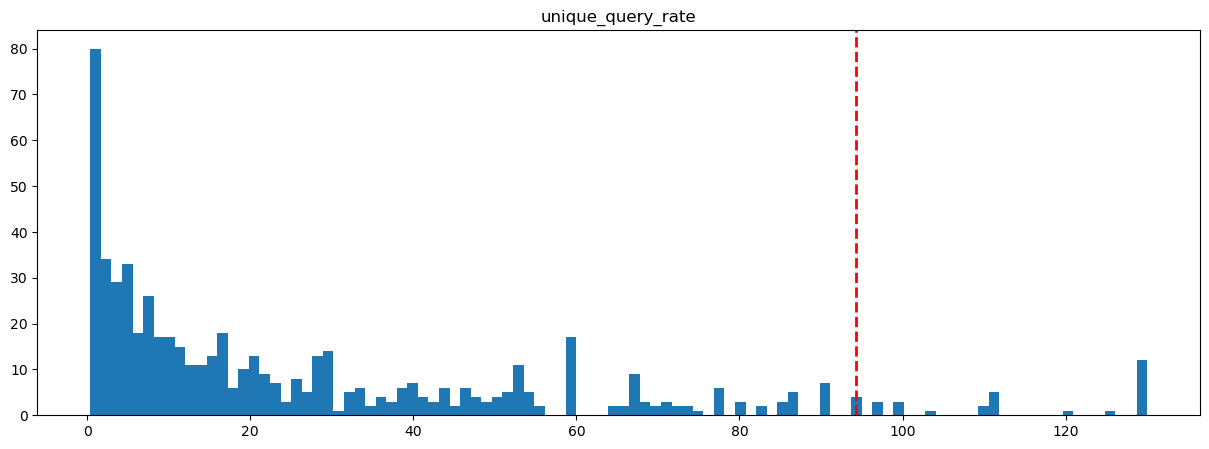

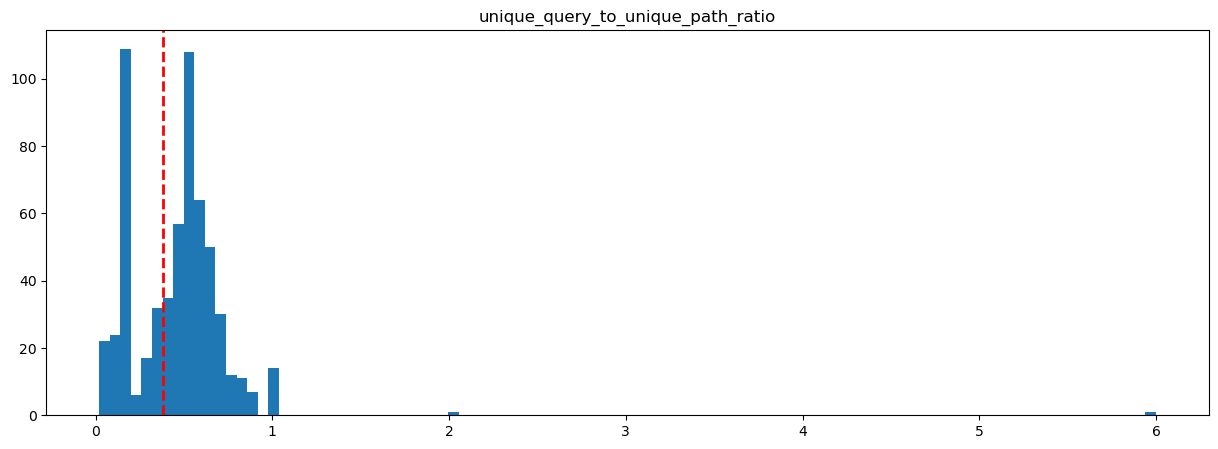

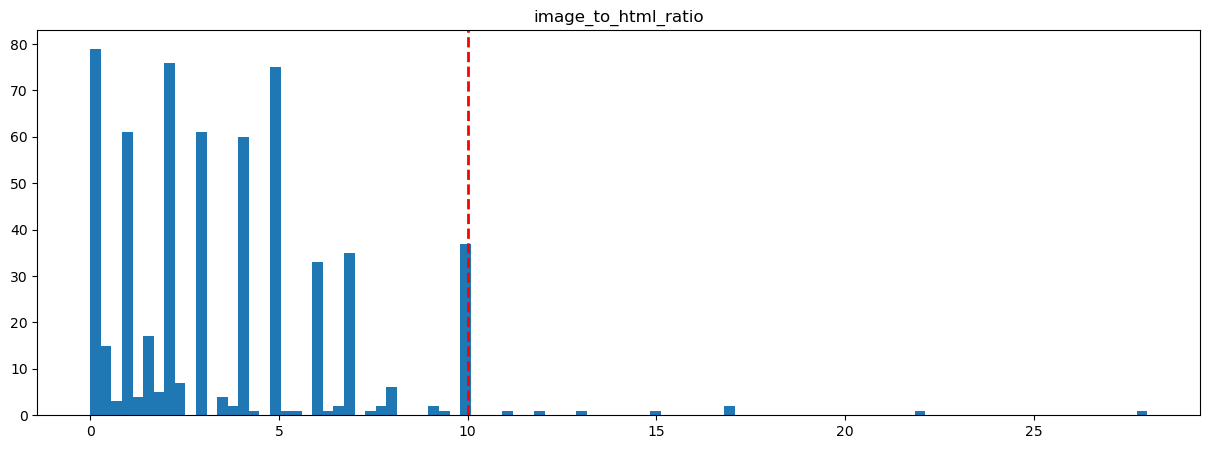

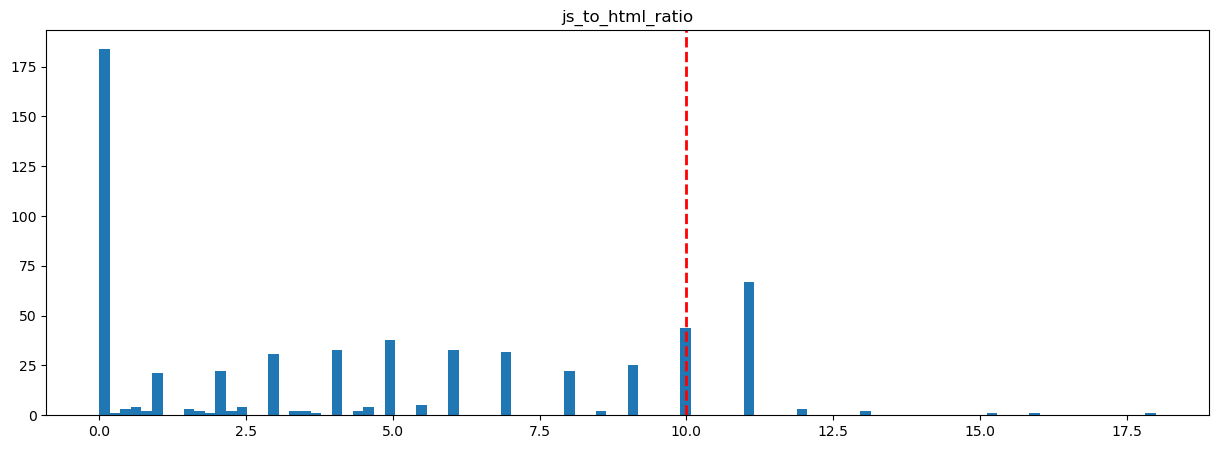

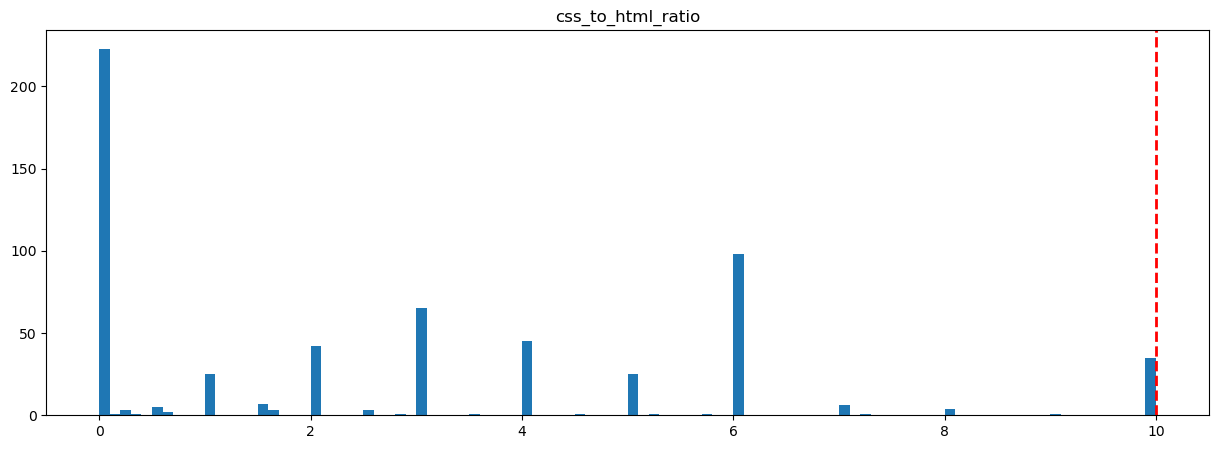

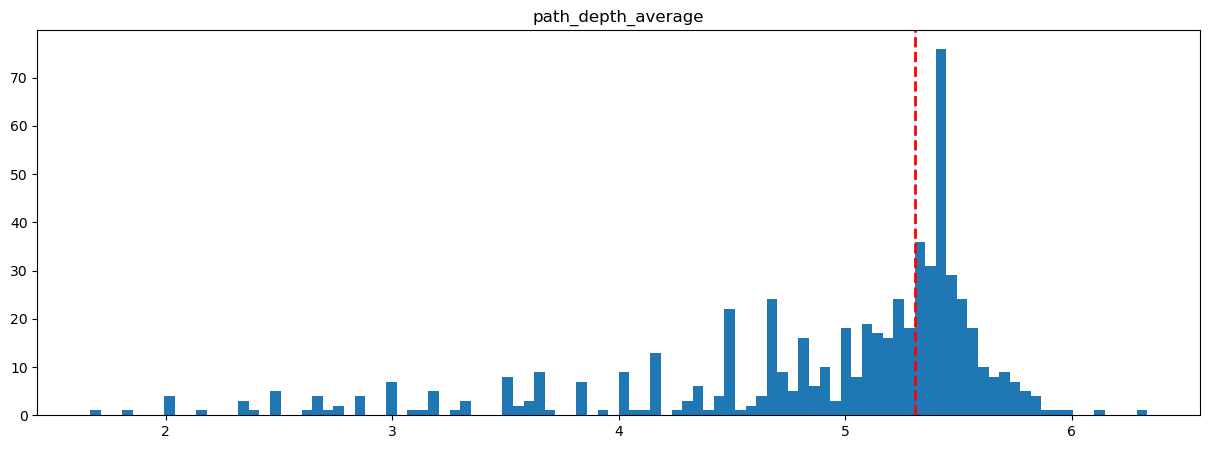

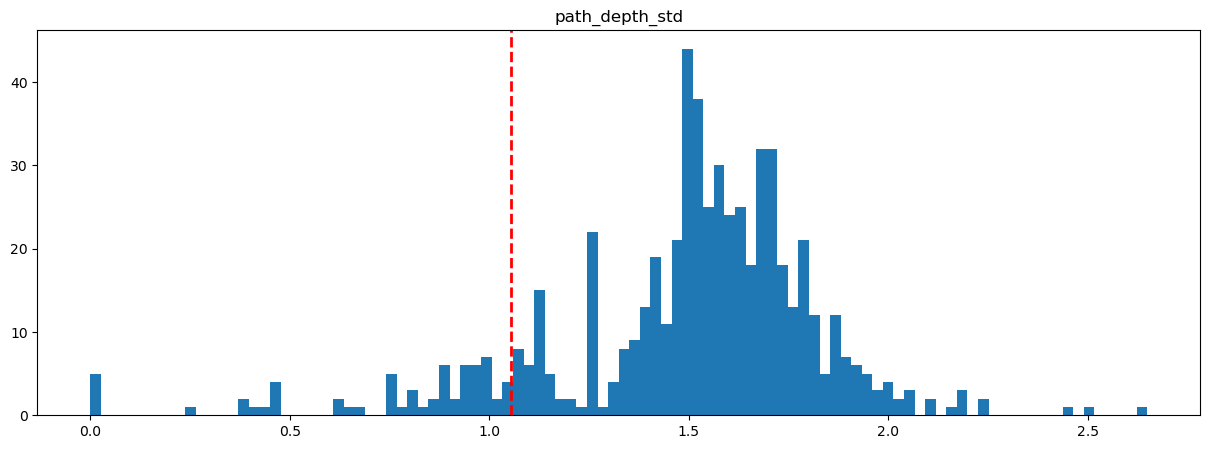

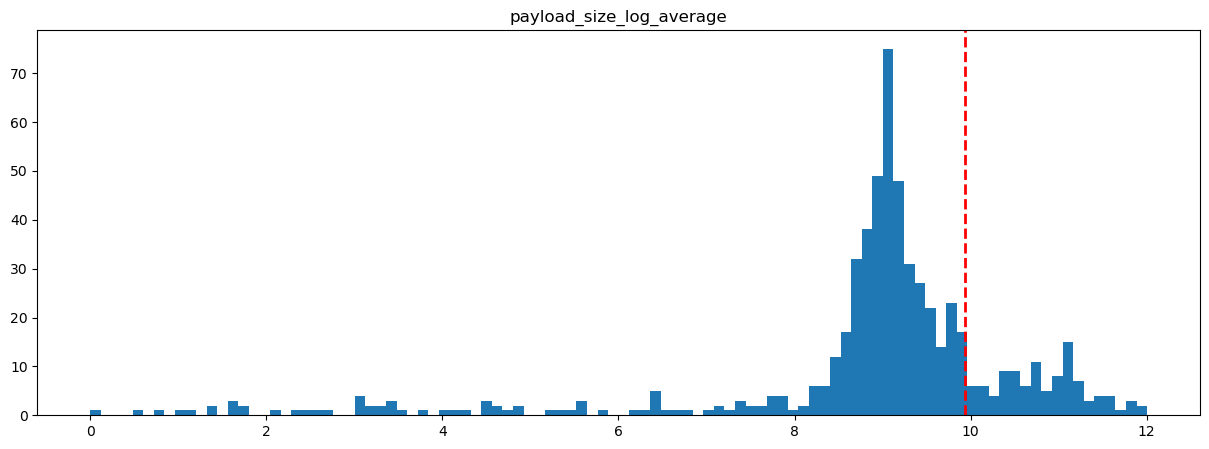

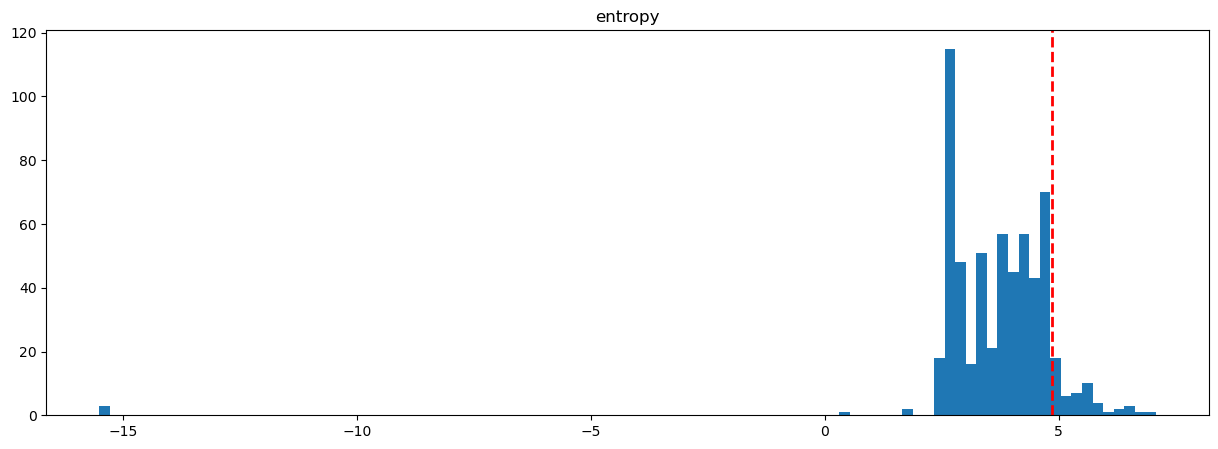

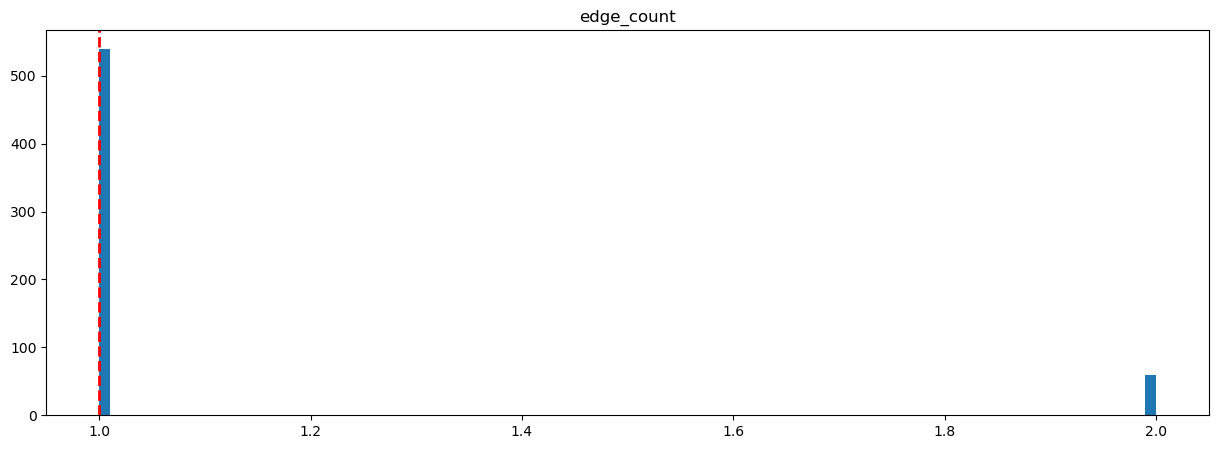

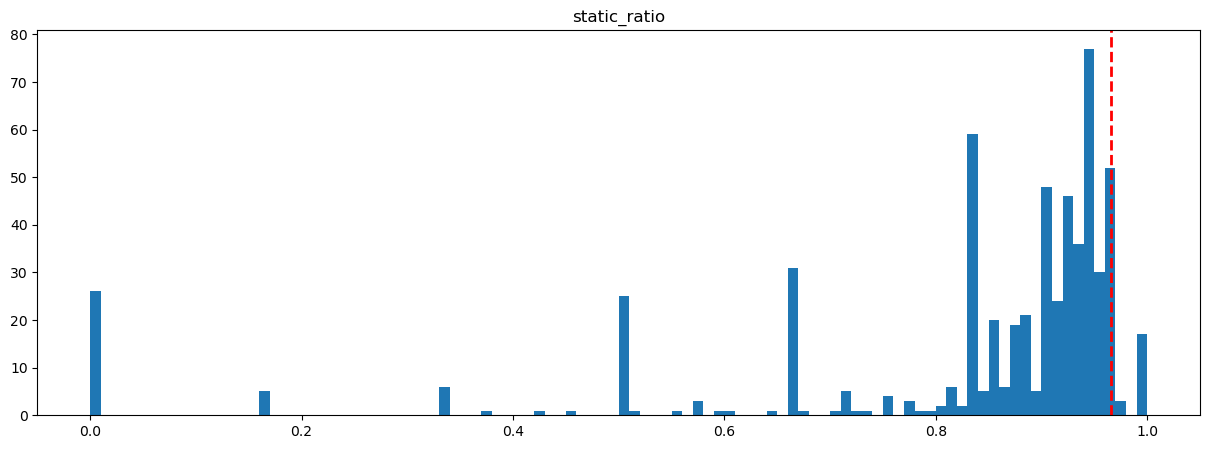

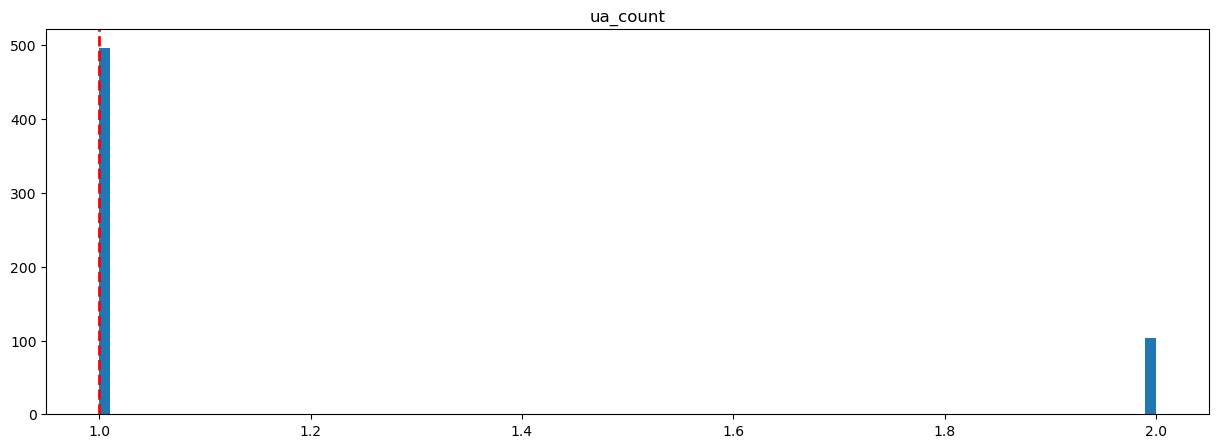

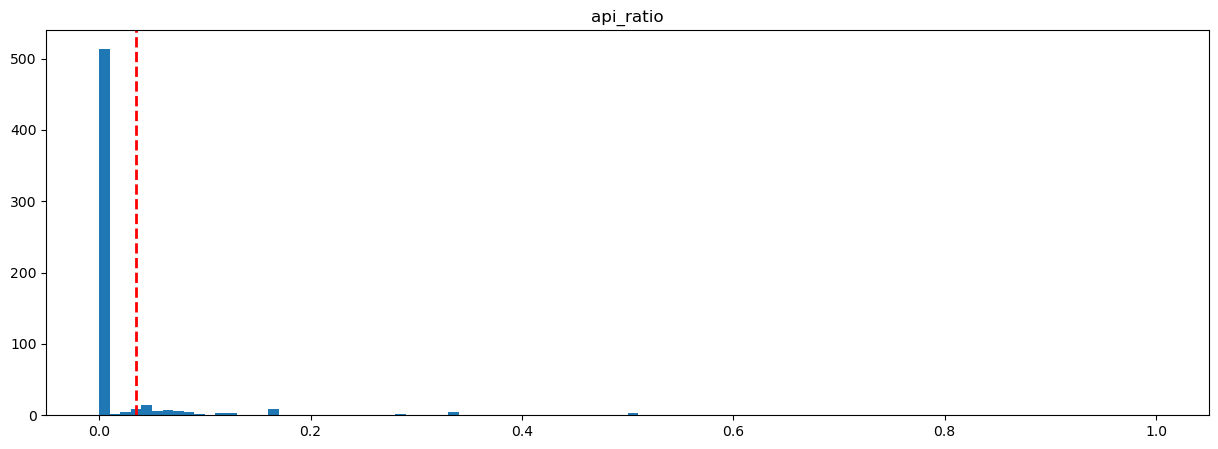

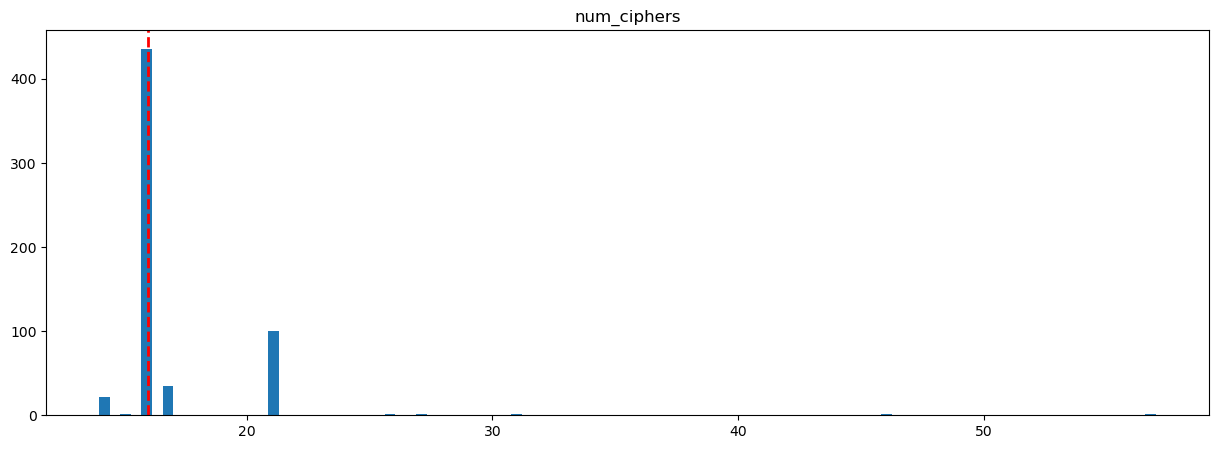

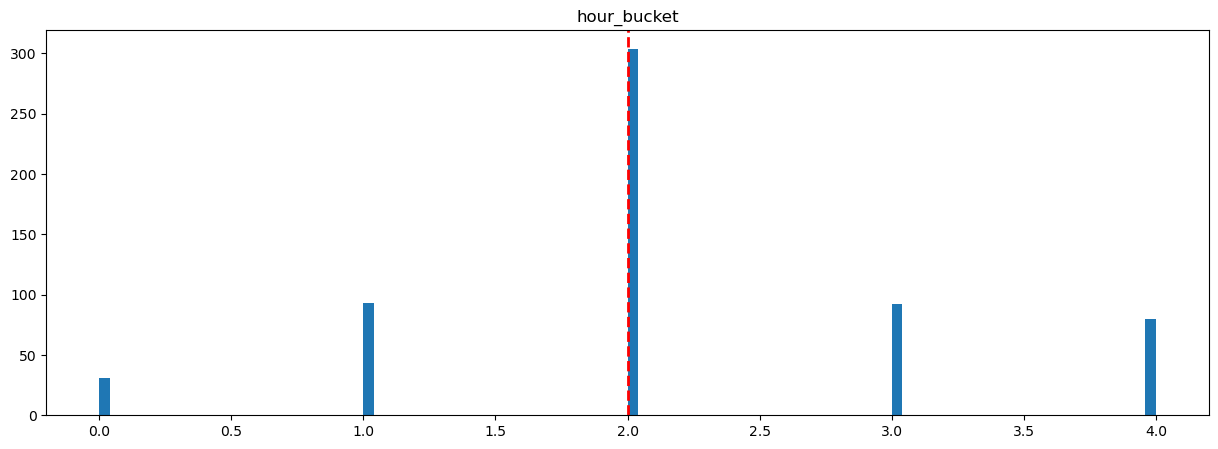

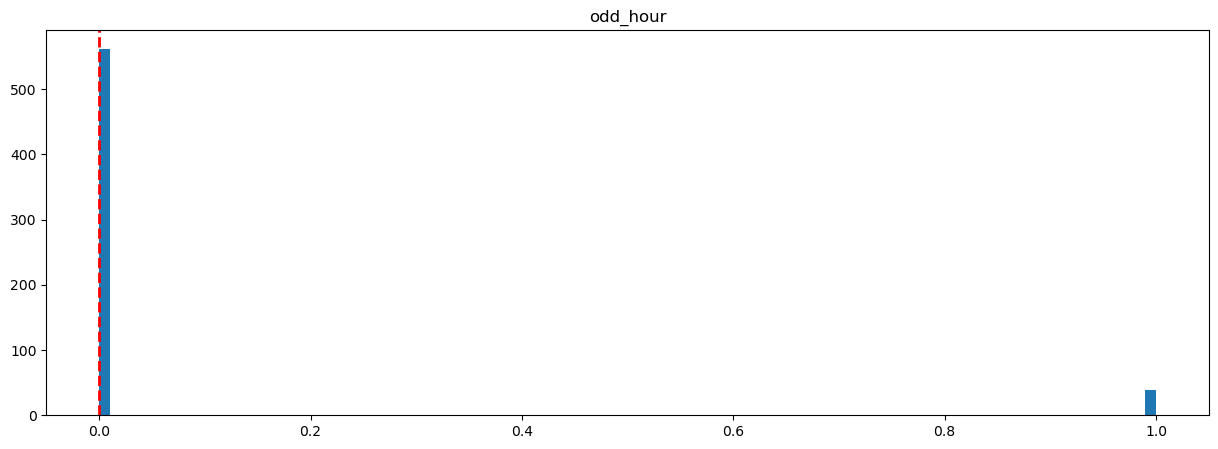

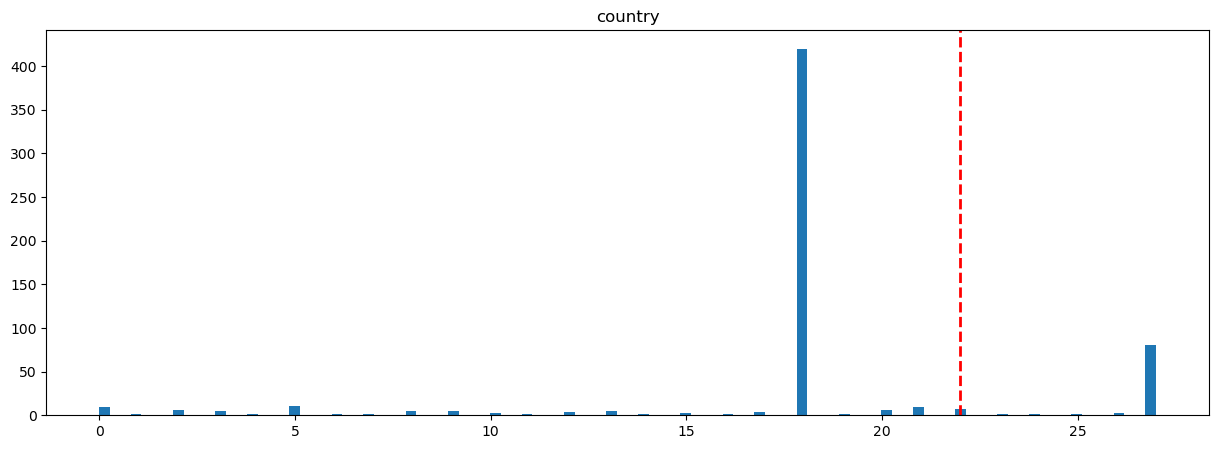

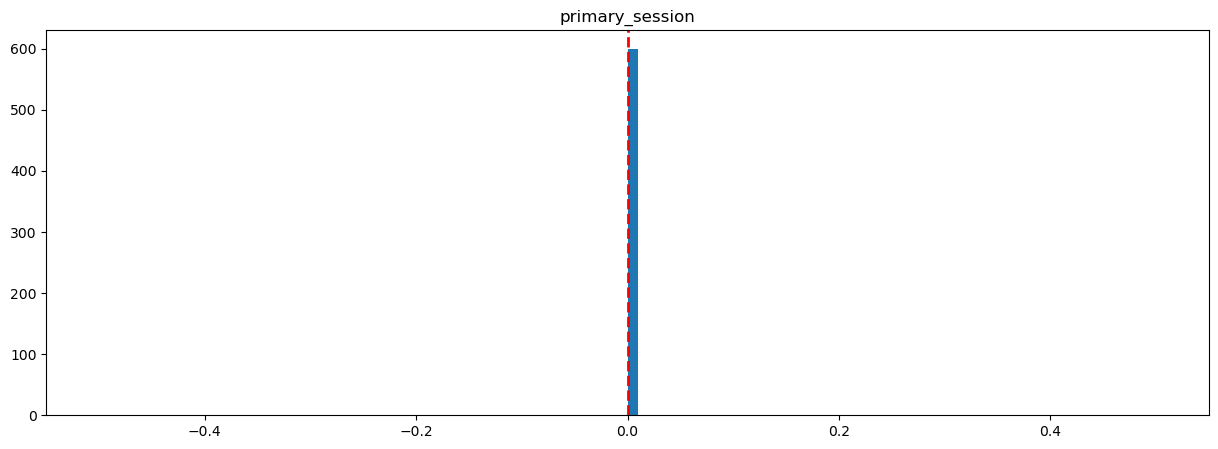

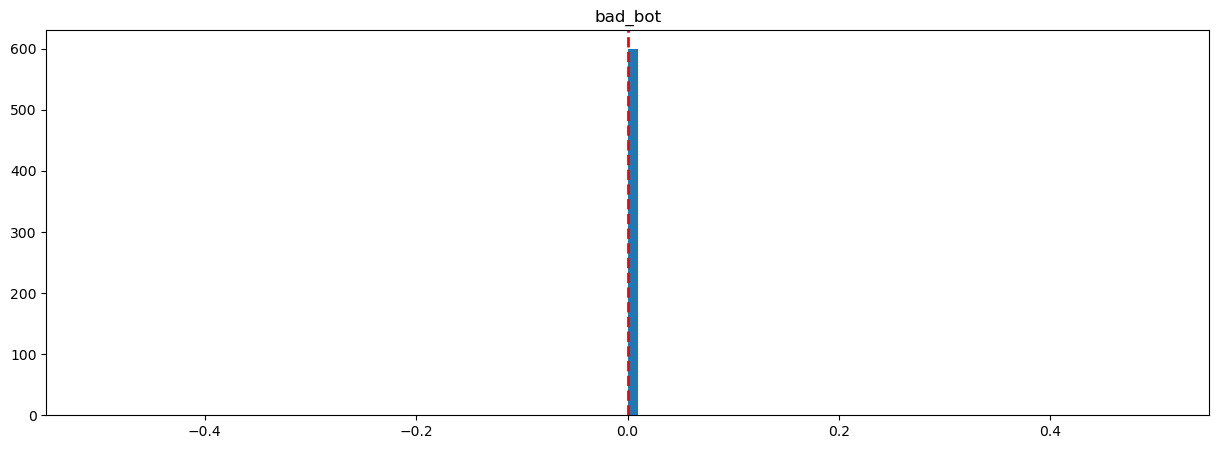

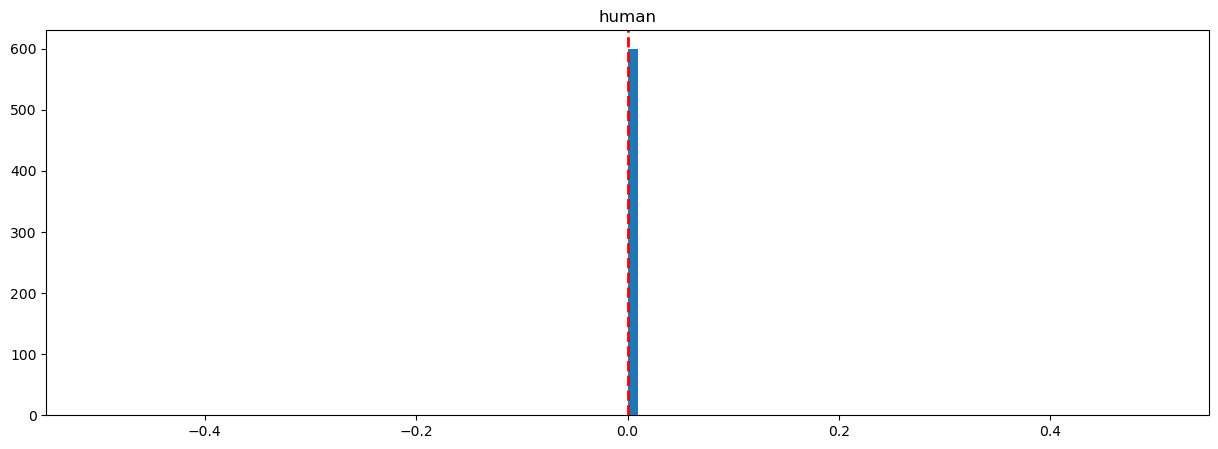

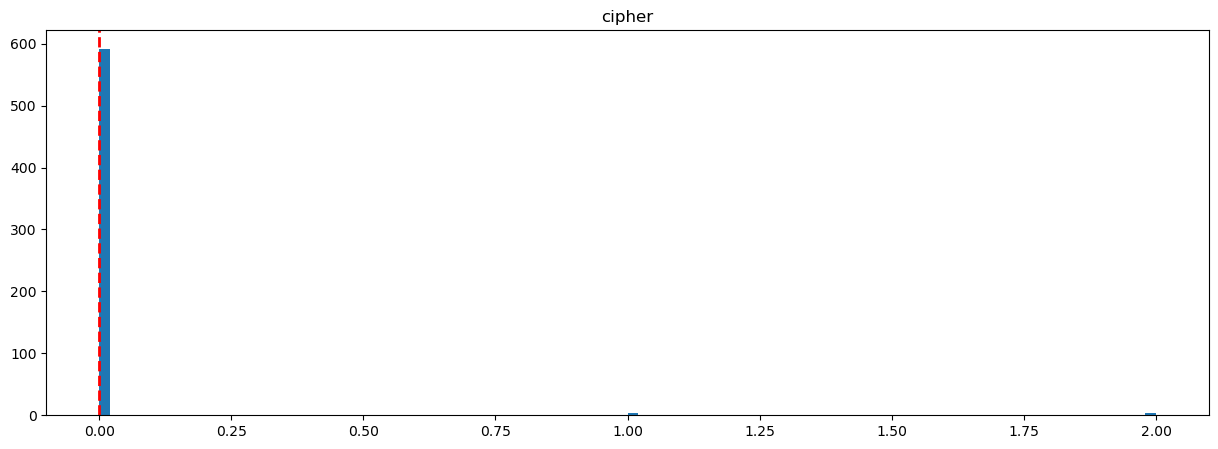

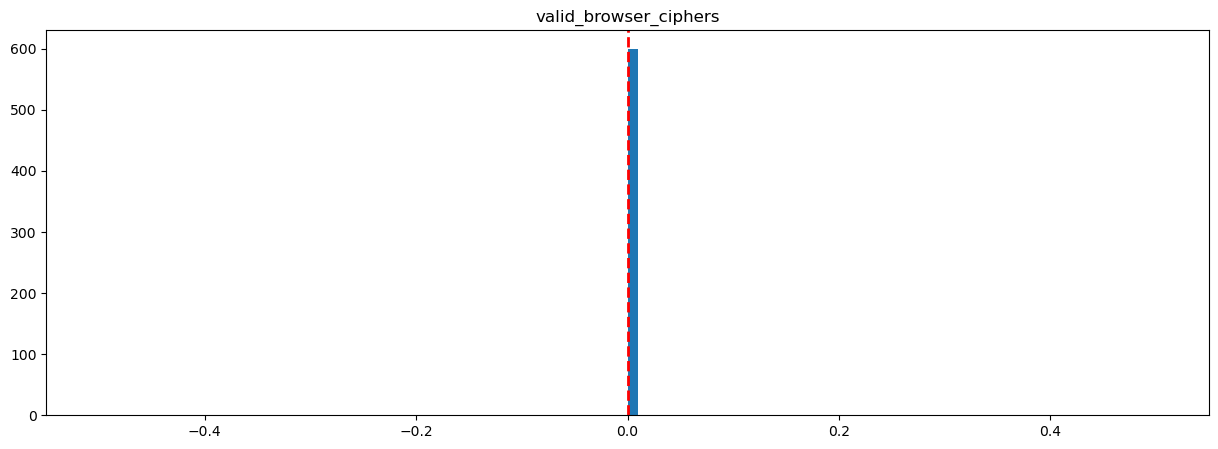

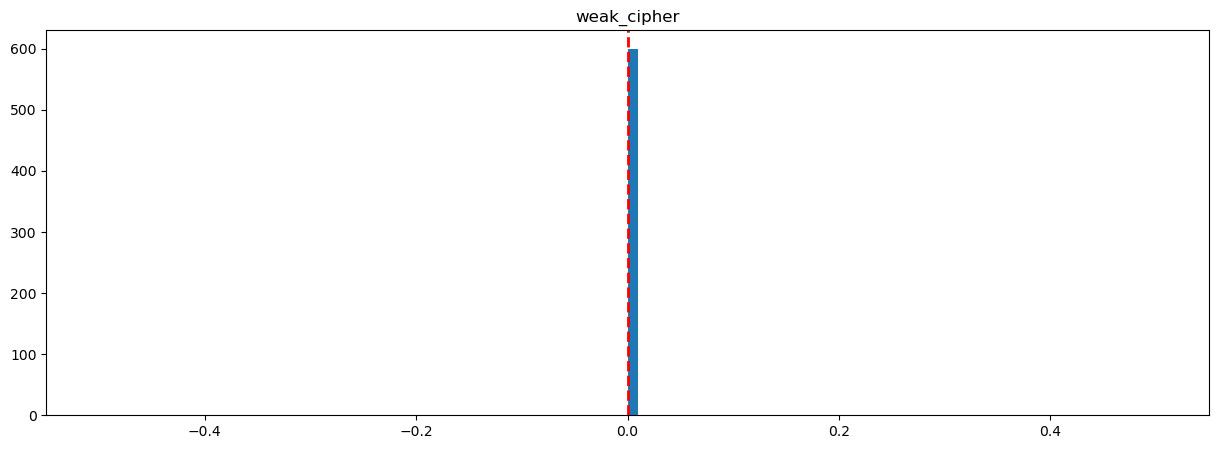

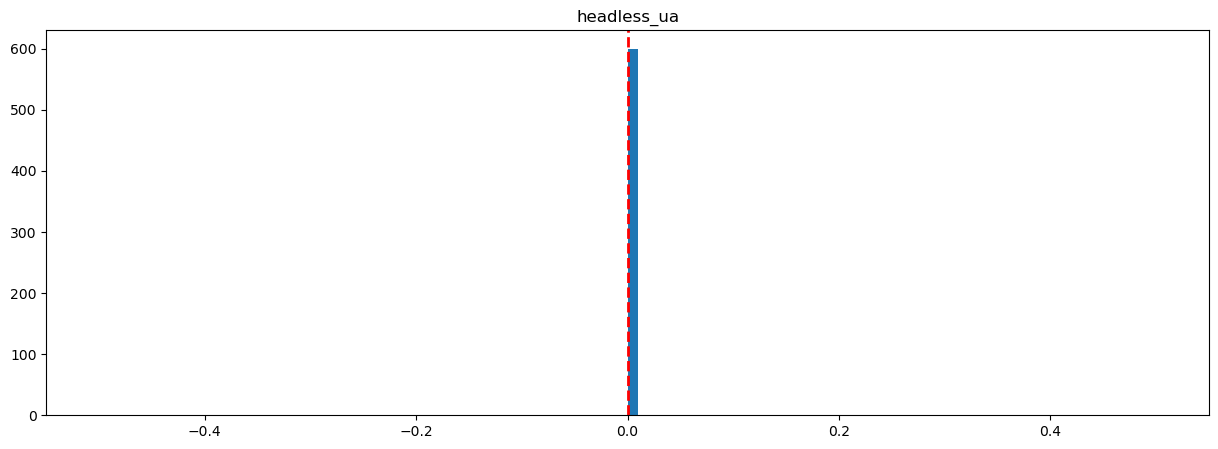

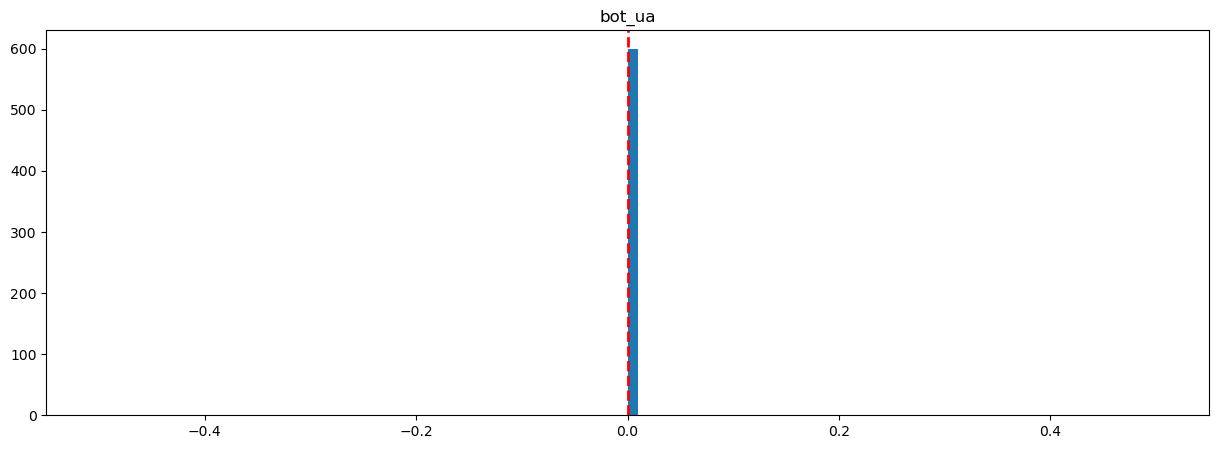

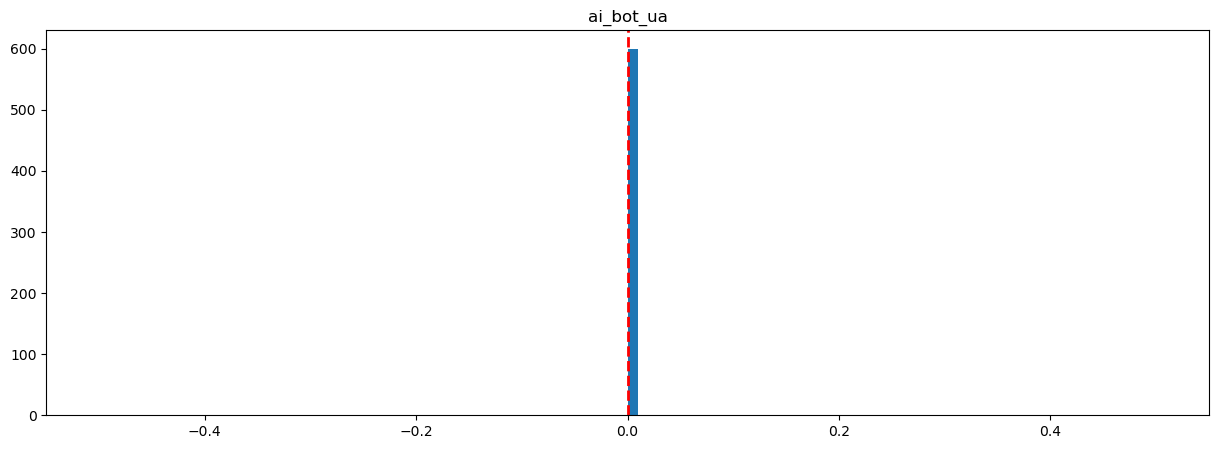

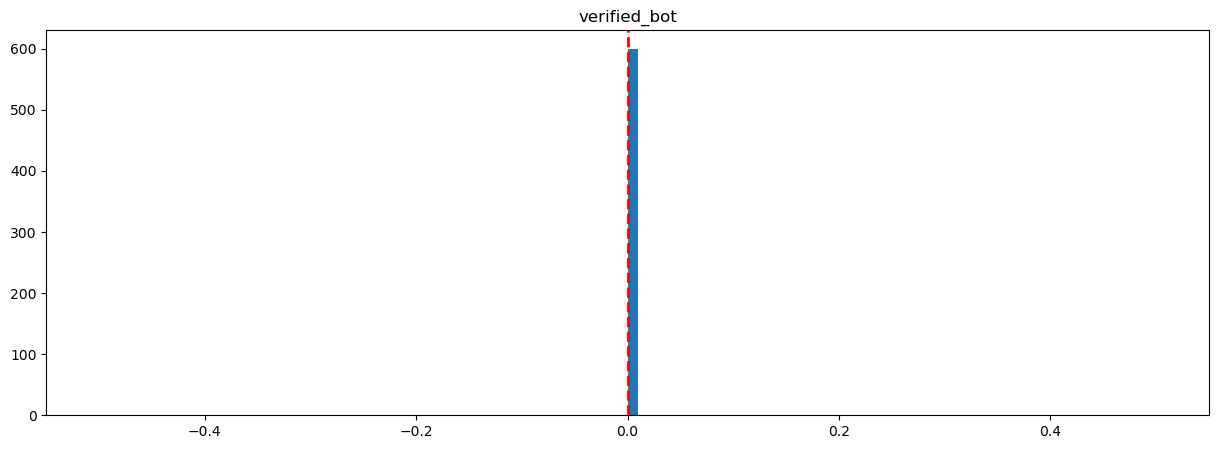

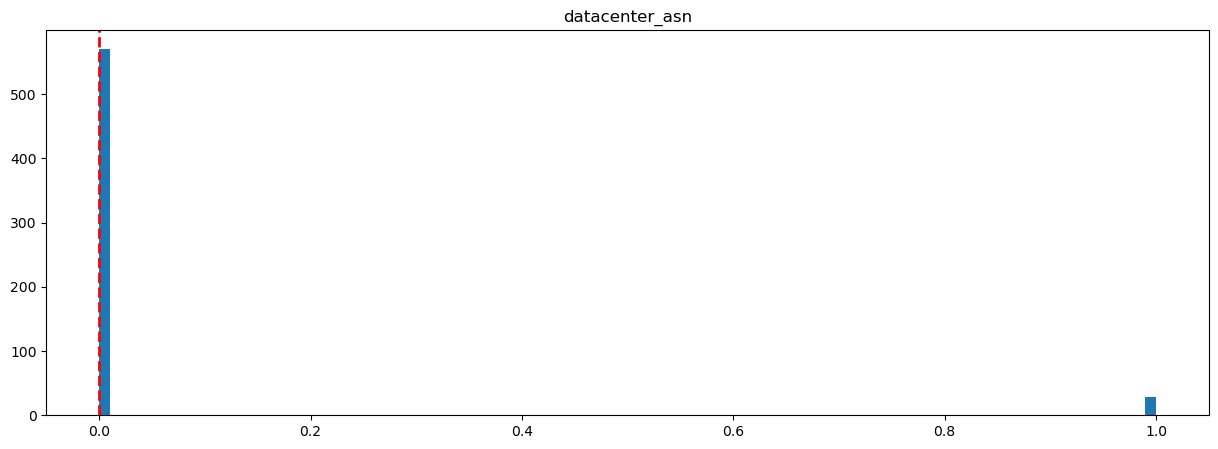

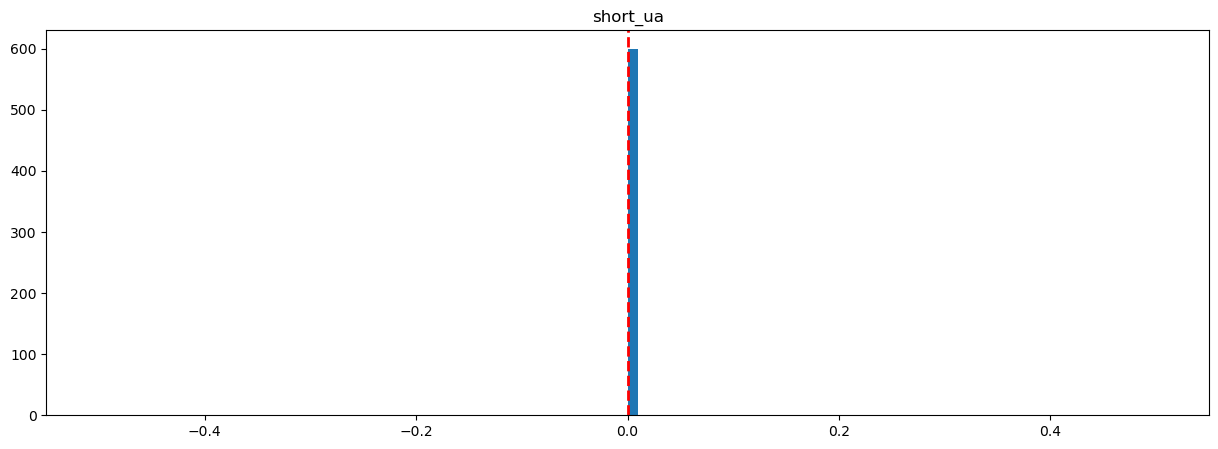

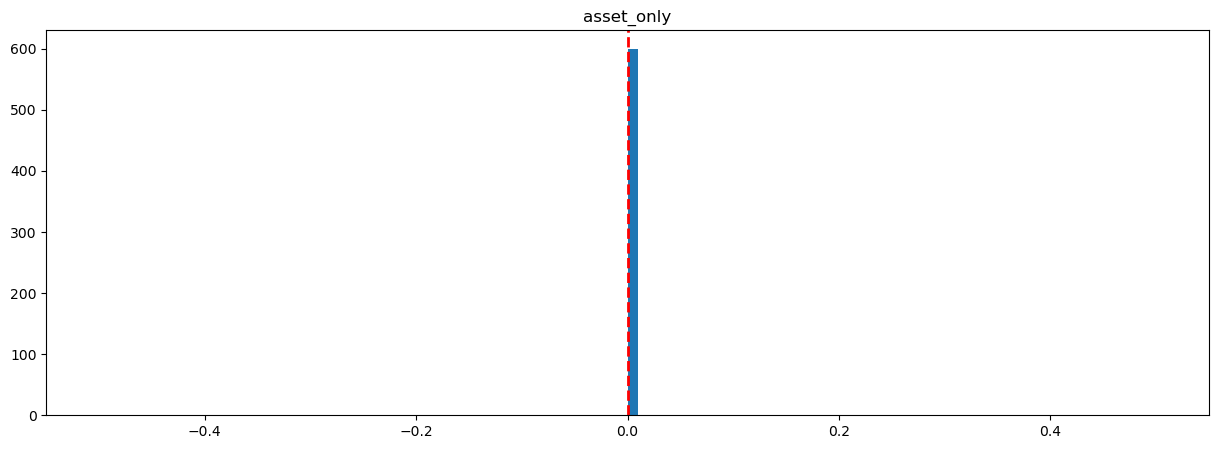

In [23]:
feature_names = fe.get_all_features()
for i in range(len(feature_names)):
    a = np.hstack(Z_train[:,i])
    _ = plt.hist(a, bins=100)  # arguments are passed to np.histogram
    plt.title(feature_names[i])
    plt.axvline(Z_train[0, i], color='red', linestyle='dashed', linewidth=2)
    plt.show()


## Home page

In [24]:
sessions[10]['human']

True

In [25]:
duration = 60
hit_rate = 2
country = 'RU'
session = {
    'duration': duration, 
    'country': country, 
    'primary_session': False, 
    'cipher': 'TLS_CHACHA20_POLY1305_SHA256',
    'human': True,
    'session_id':'-'}
requests = []
num_hits = int(duration * hit_rate / 60)
ts = datetime.now()
time_increment = 60.0 / hit_rate

for i in range(num_hits):
    requests.append({'ts': ts, 
                     'url': sessions[10]['requests'][0]['url'],
                     # 'url': '/', 
                     # 'url': f'{i%3}',
                     'query': f'{i}', 
                     # 'ua': 'ddd',
                     'ua': f'{i}-mozilla/5.0 (compatible; msie 9.0; windows; u; windows nt 6.2;; en-us trident/5.0)',
                     'code': 200, 
                     'type': 'text/html',
                     'method': 'GET',
                     'payload': 100})
    ts += timedelta(seconds=time_increment)
session['requests'] = requests


print('Isolation Forest')
ts = datetime.now()
score, shapley = model.transform([session])
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'hits={len(session["requests"])}')
print(f'Score = {score}')
for sv in get_shapley_features(model, shapley[0]):
    print(f'{sv[1]:.2f} : {sv[0]} --> {sv[2]:.2f}')


Isolation Forest


KeyError: 'num_languages'

In [142]:
Z = np.array(fe.transform([session]))

In [143]:
sessions[1]['duration'], len(sessions[1]['requests'])

(24.0, 6)

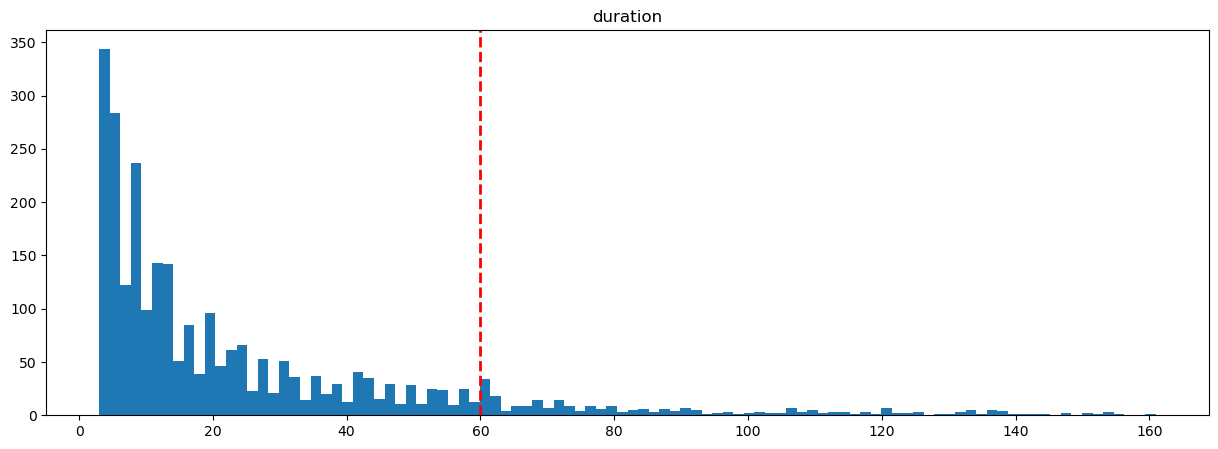

In [144]:
durations = [s['duration'] for s in sessions]
a = np.hstack(durations)
_ = plt.hist(a, bins=100)  
plt.title('duration')
plt.axvline(session['duration'], color='red', linestyle='dashed', linewidth=2)
plt.show()

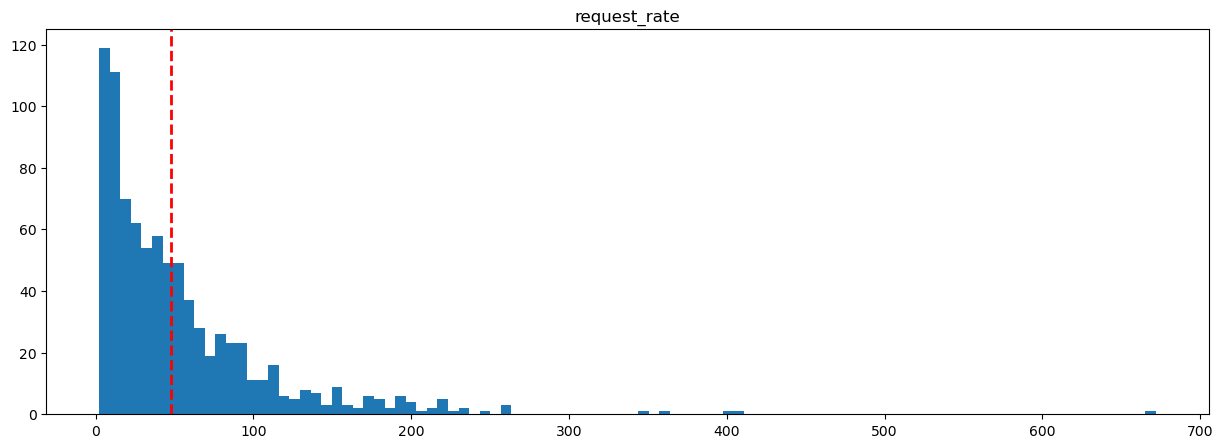

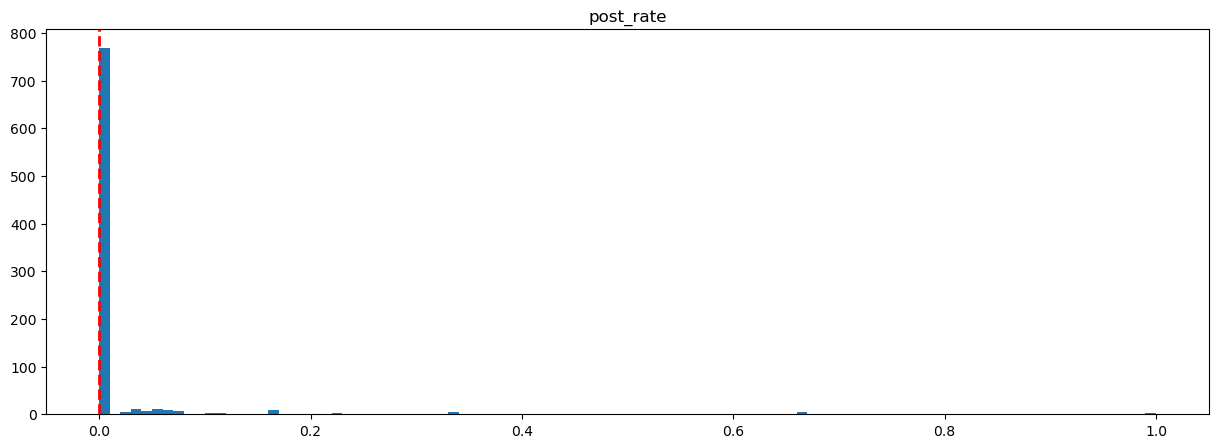

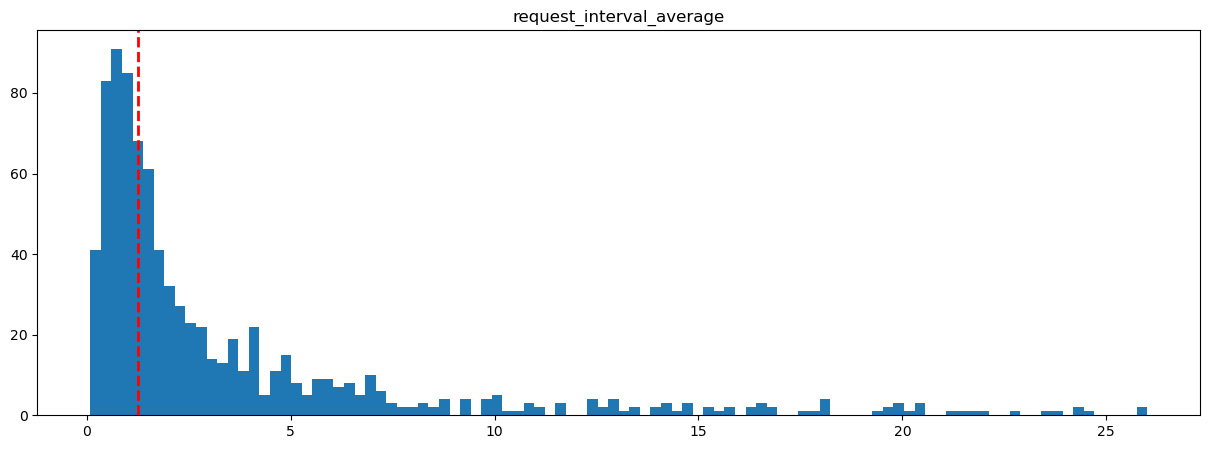

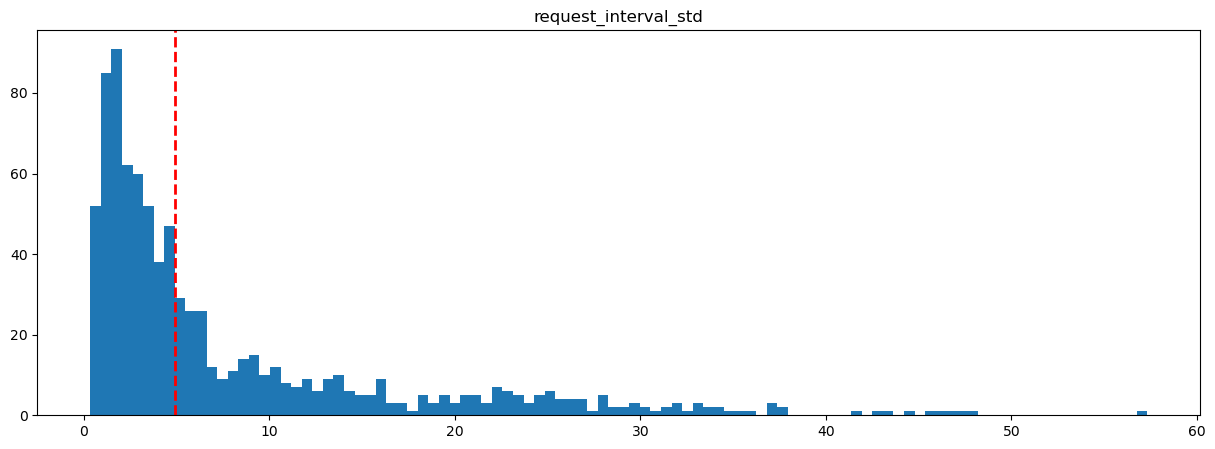

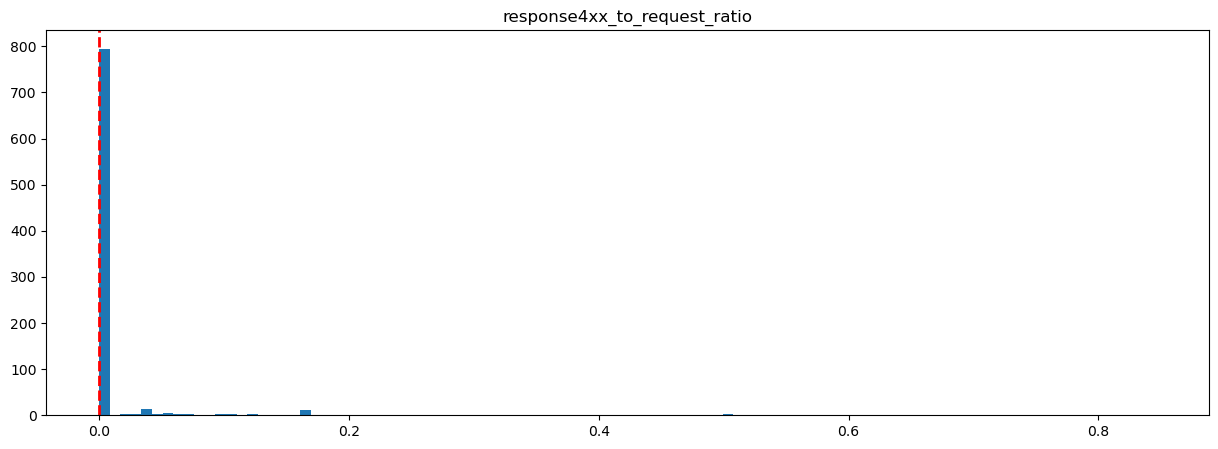

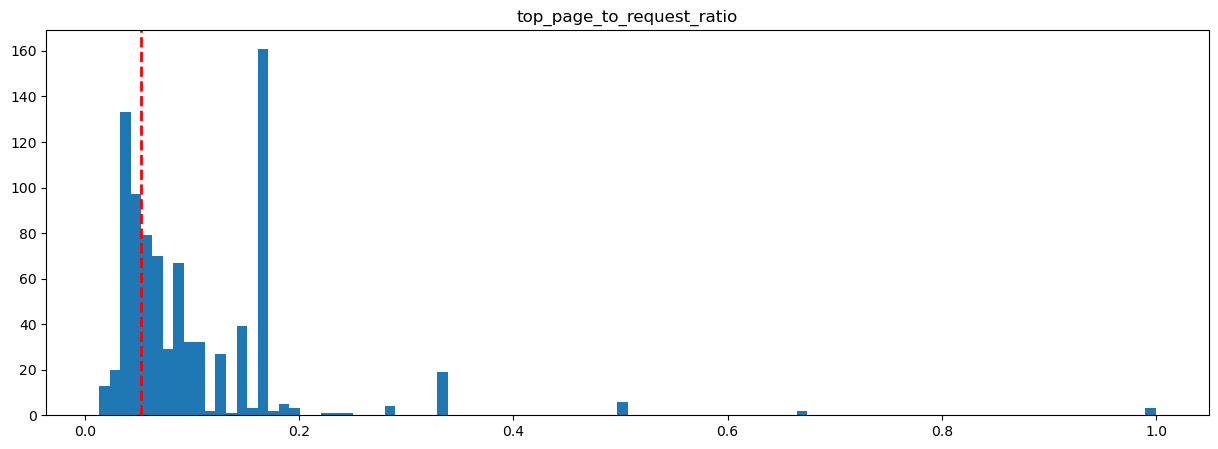

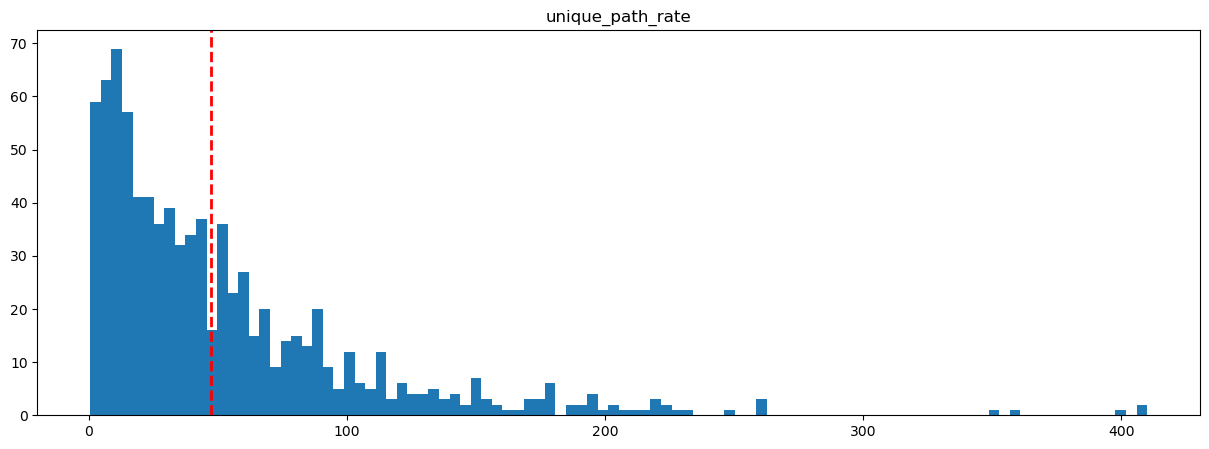

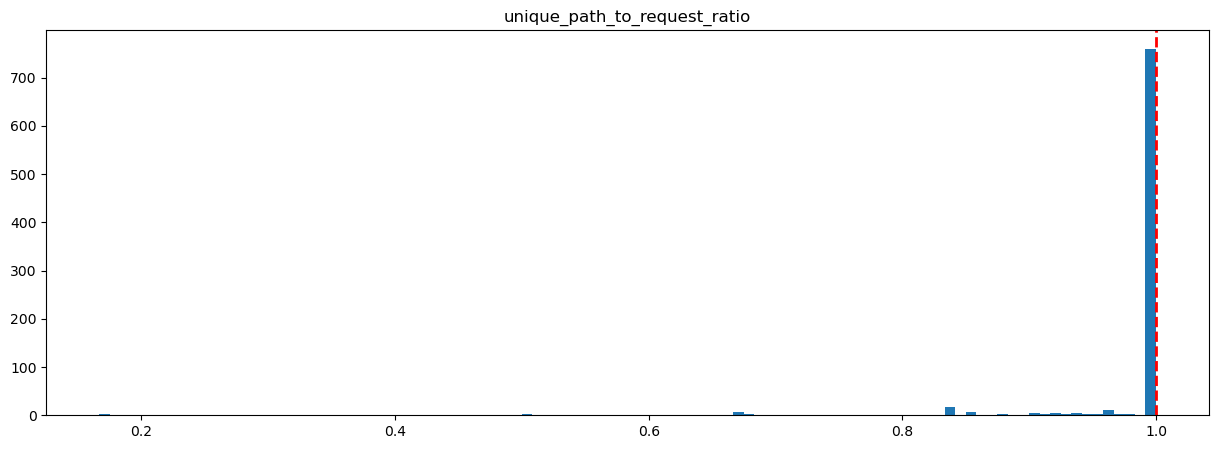

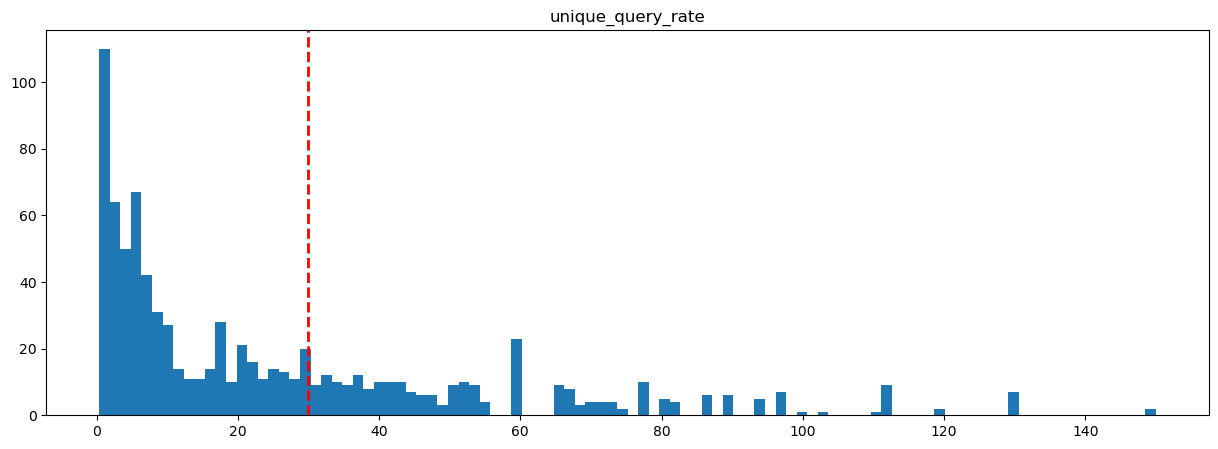

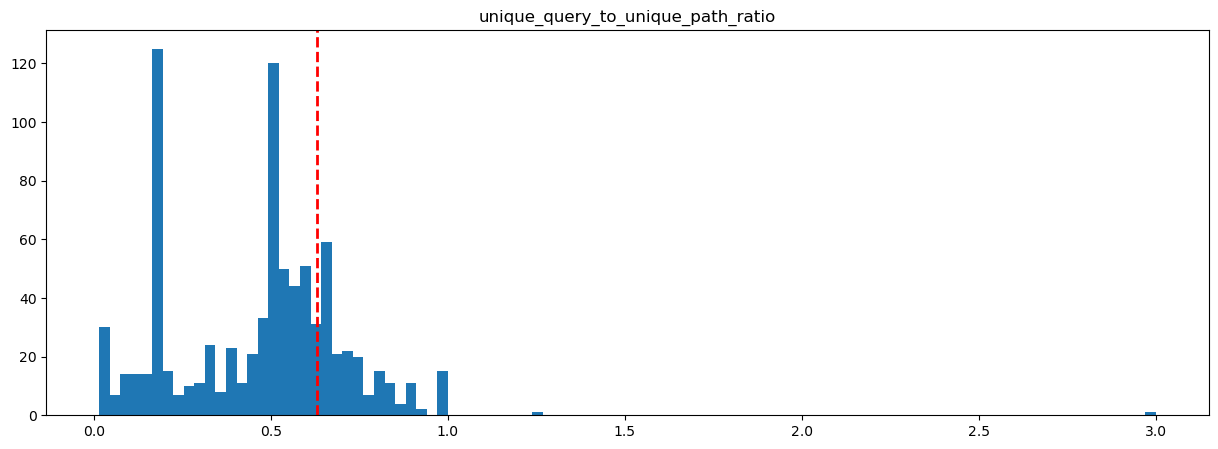

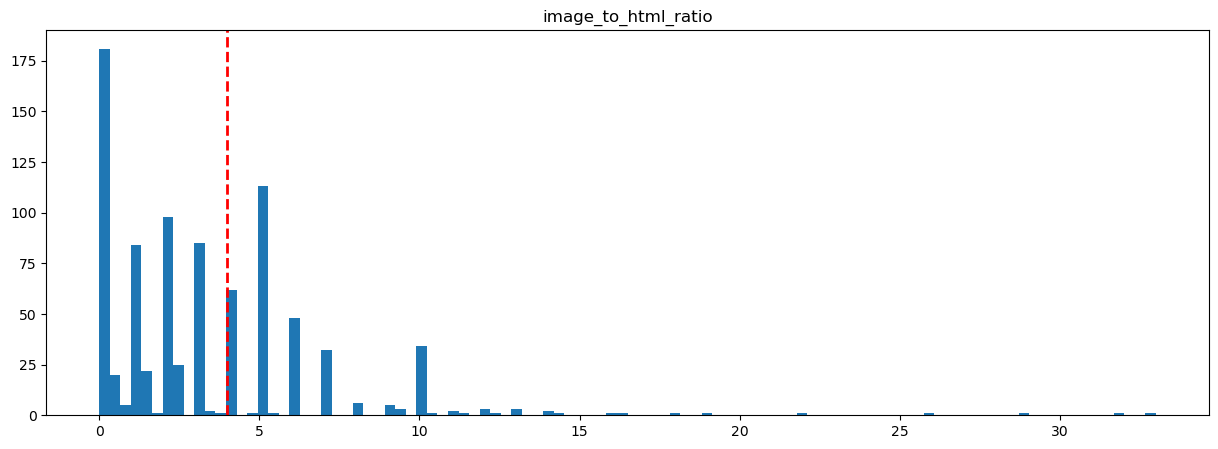

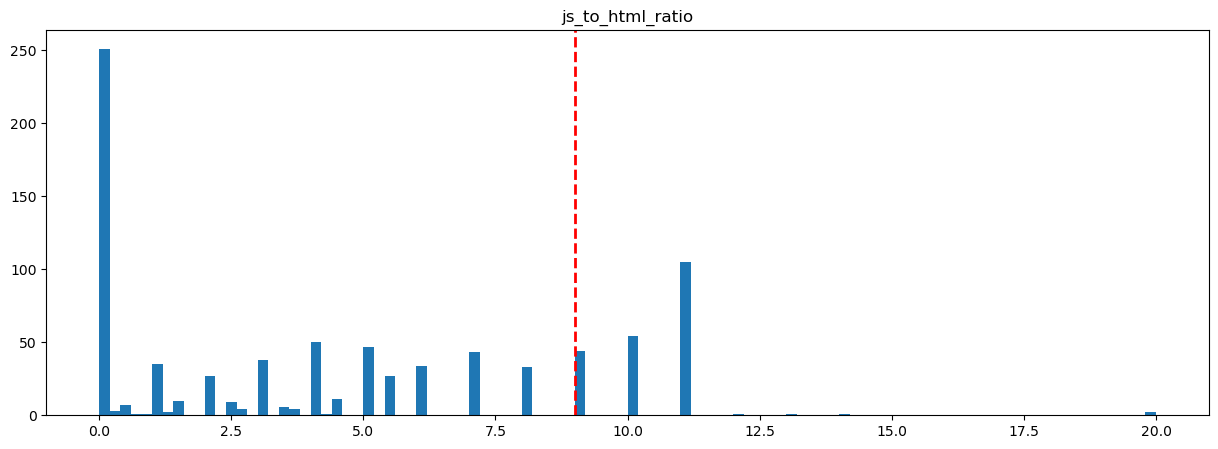

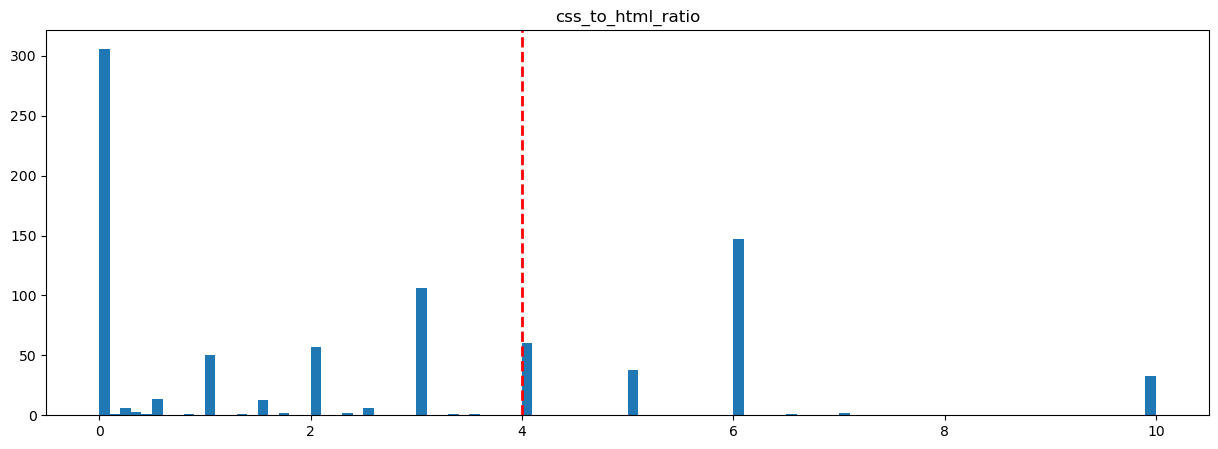

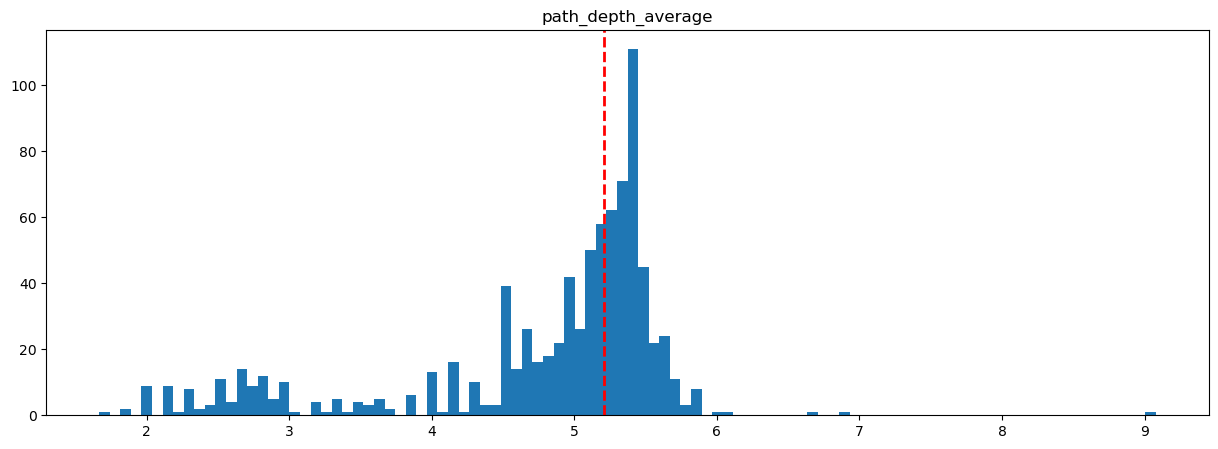

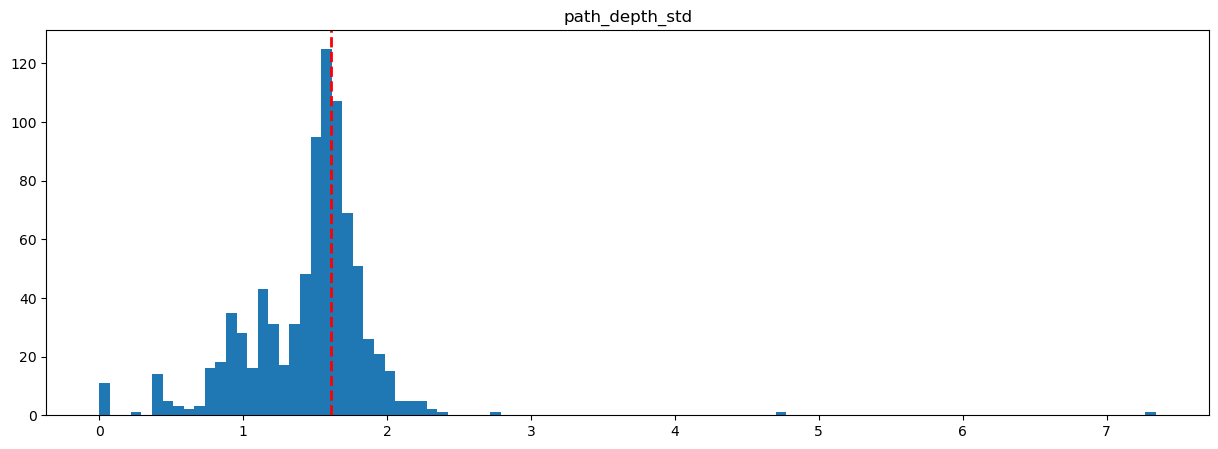

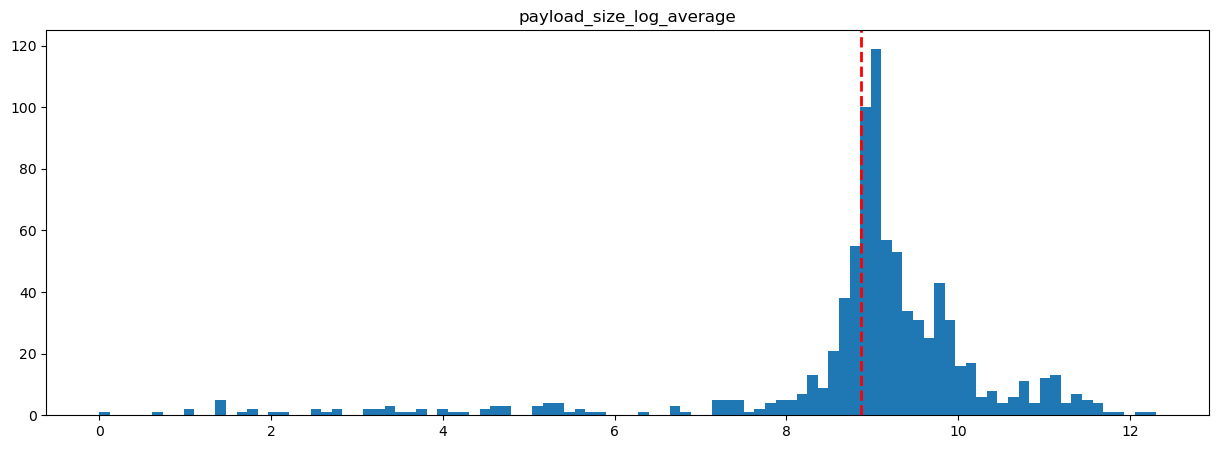

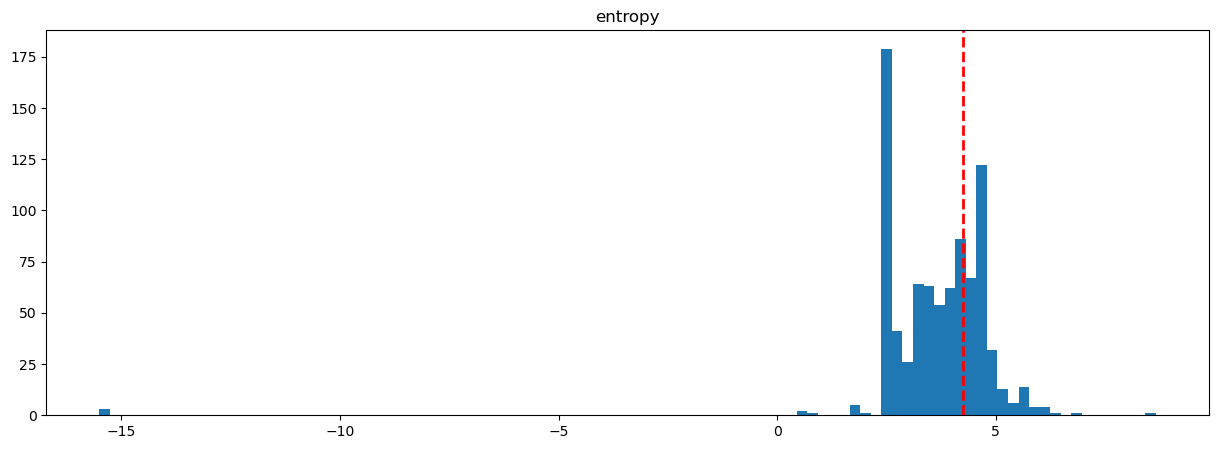

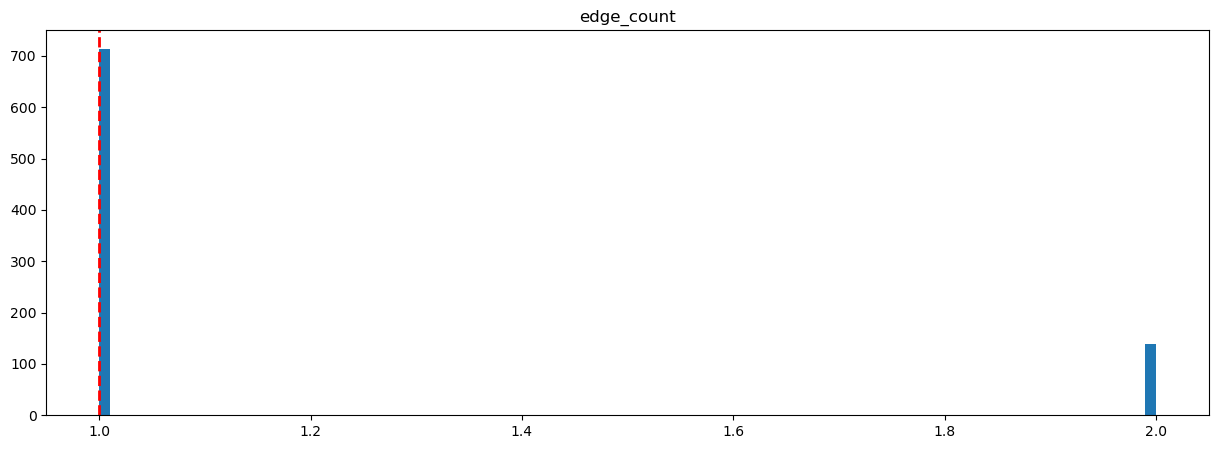

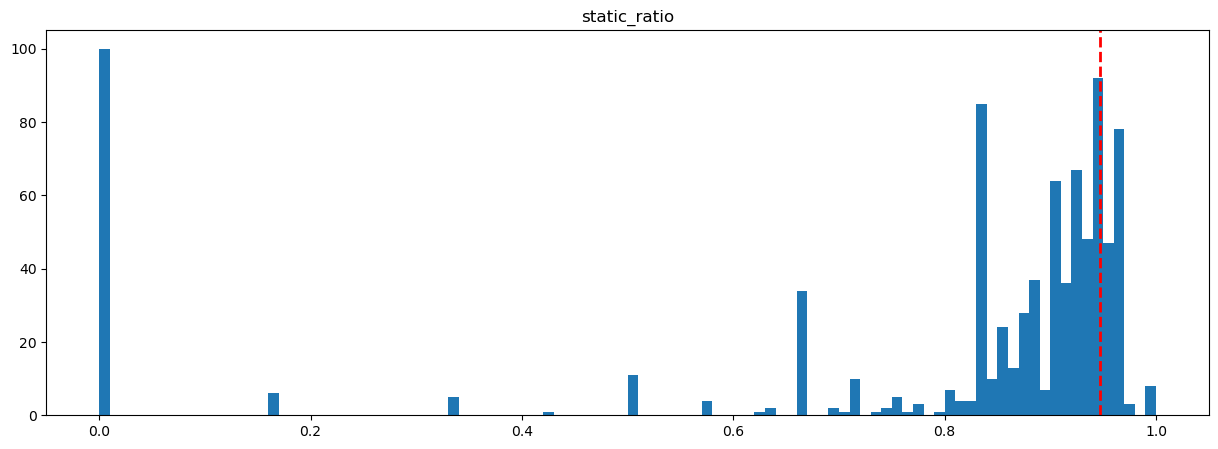

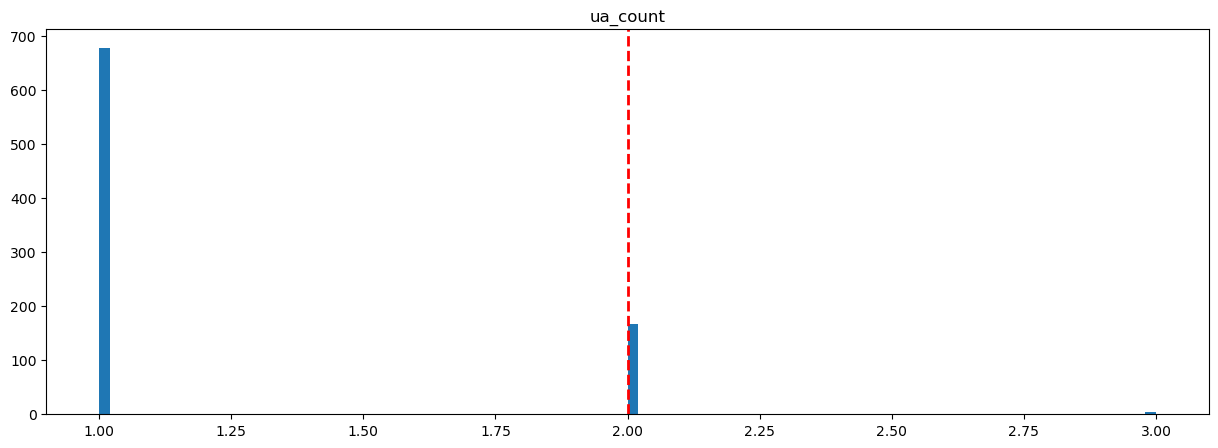

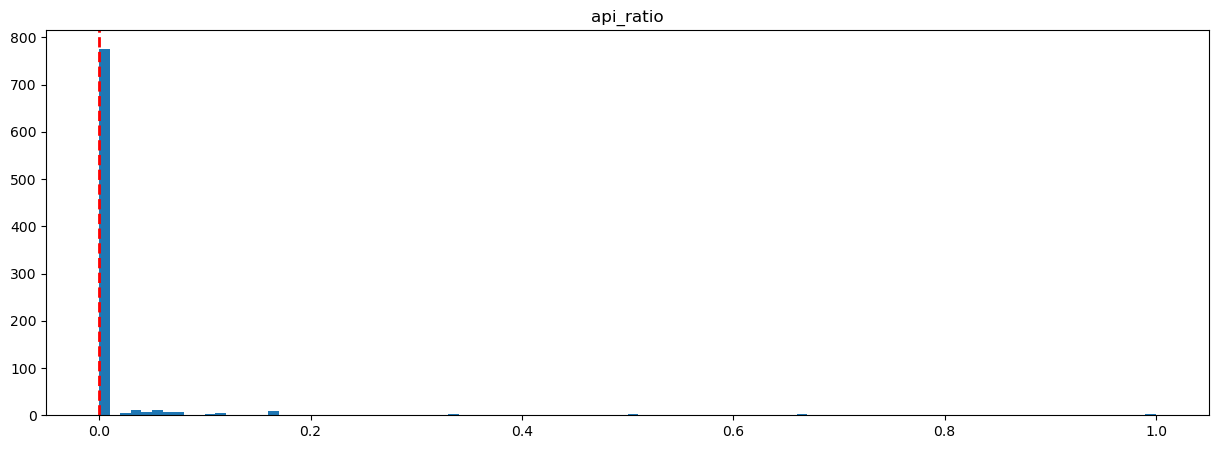

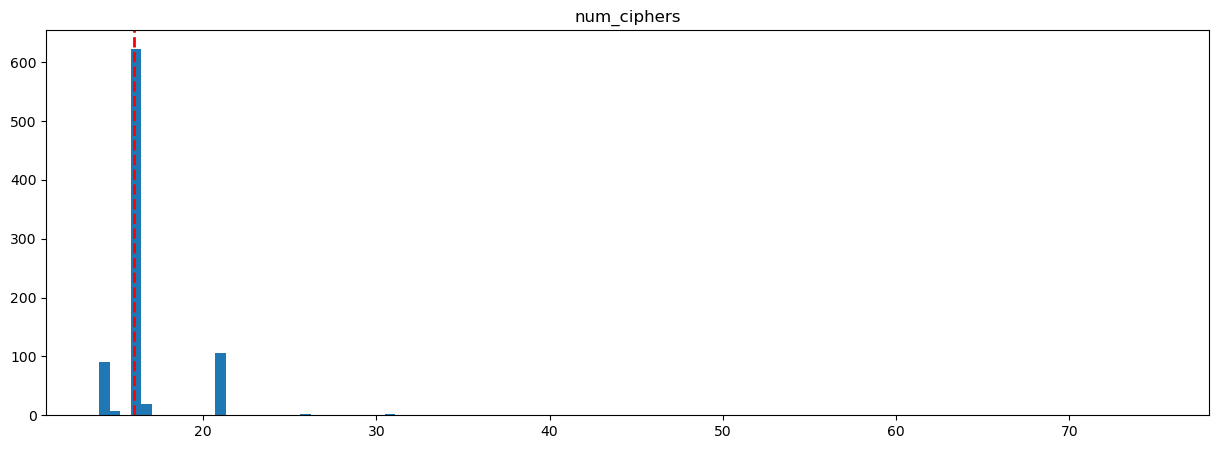

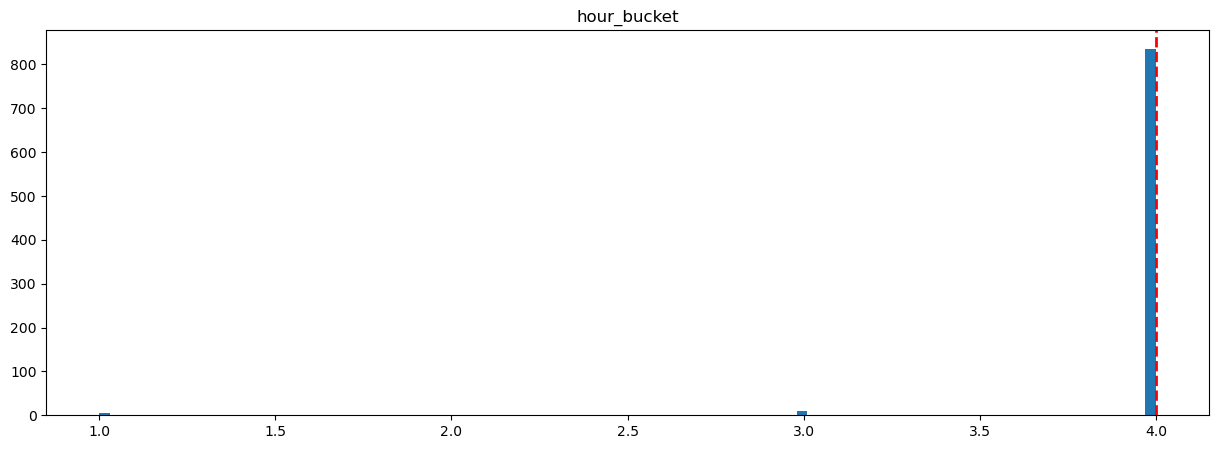

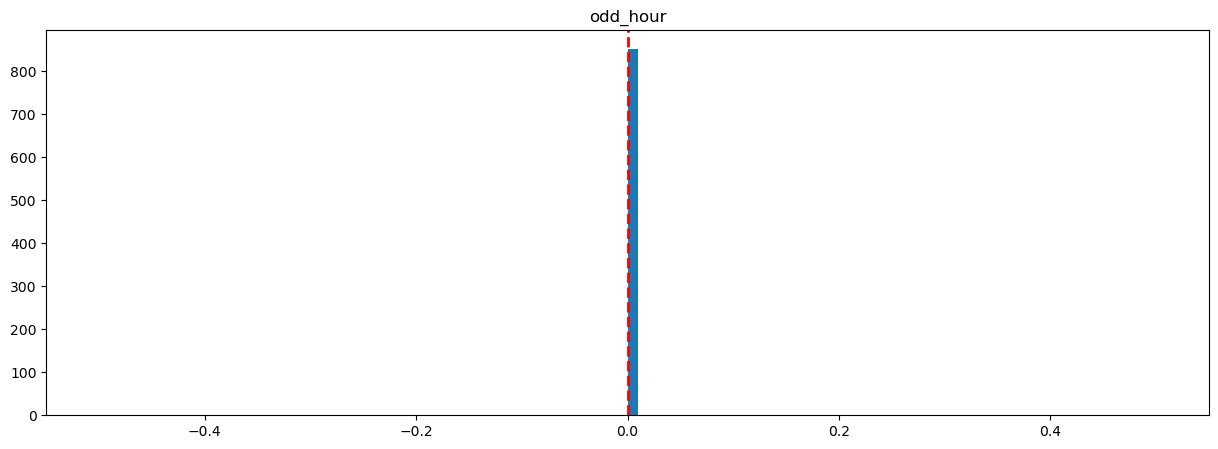

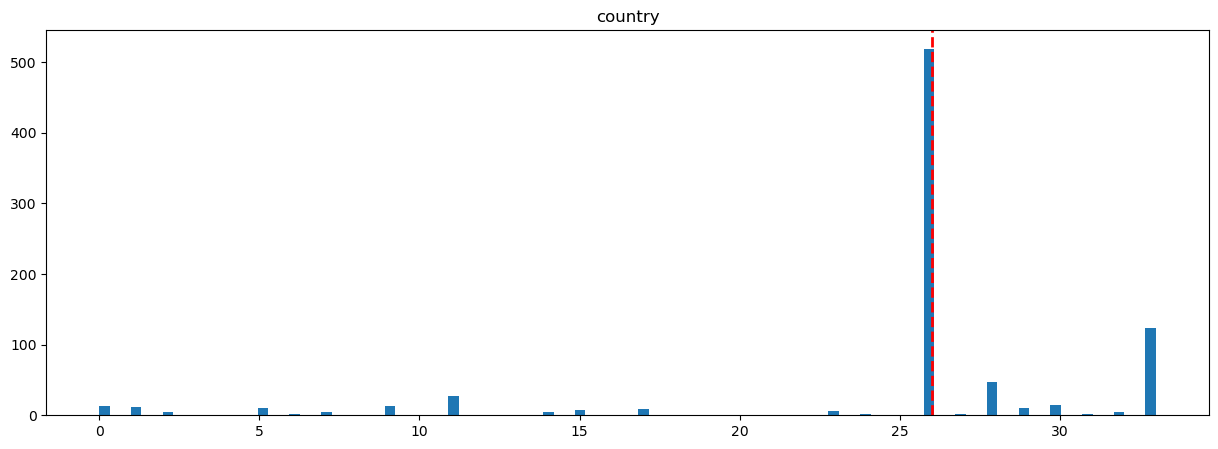

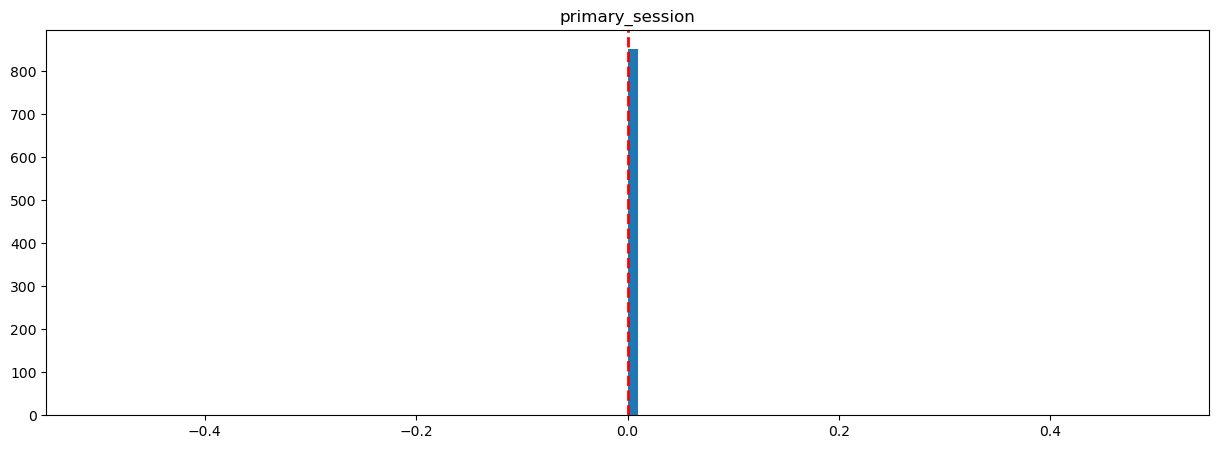

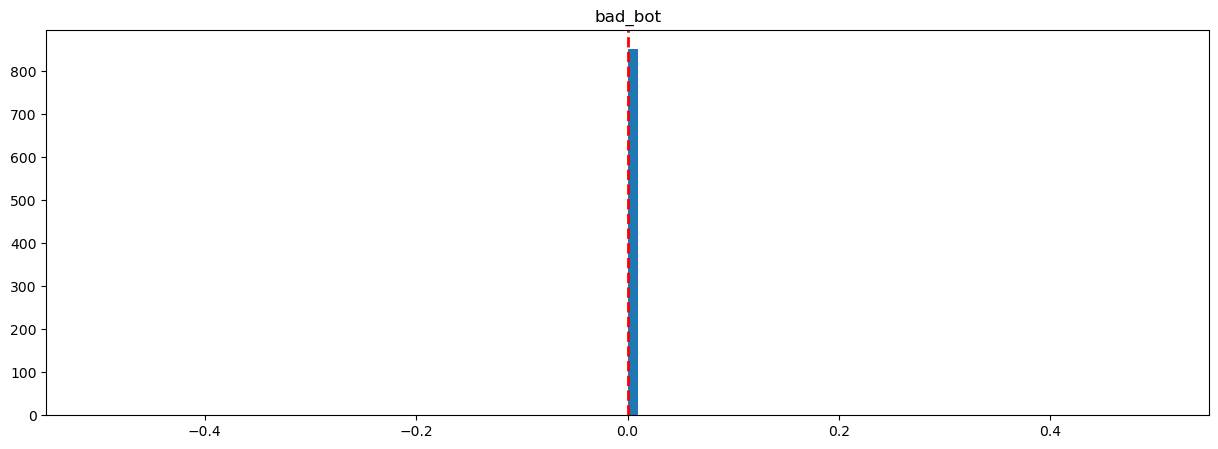

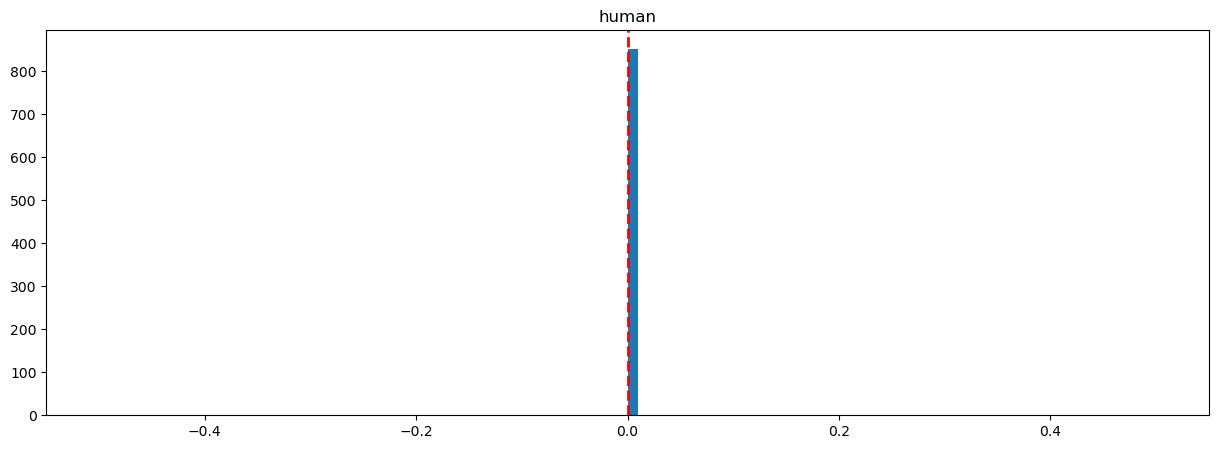

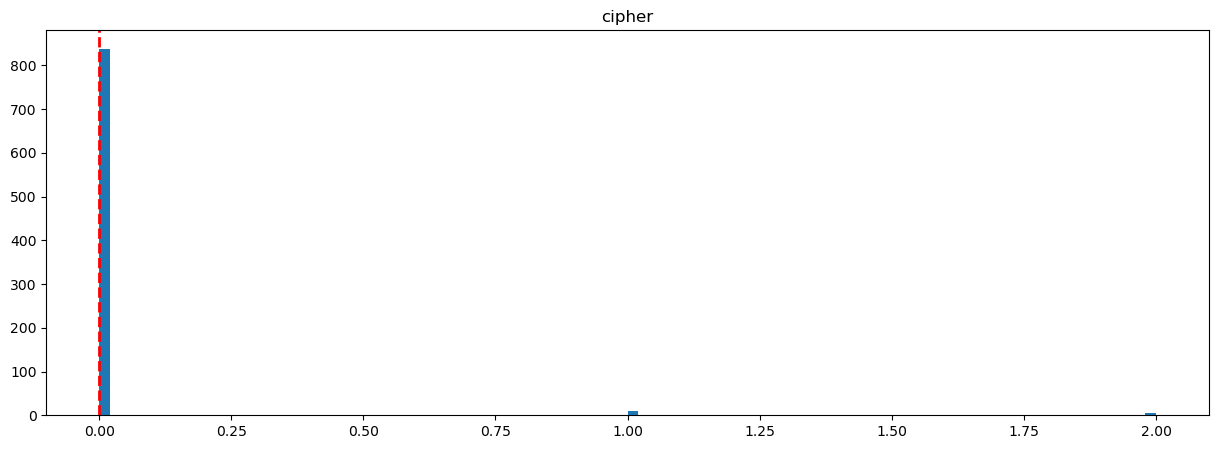

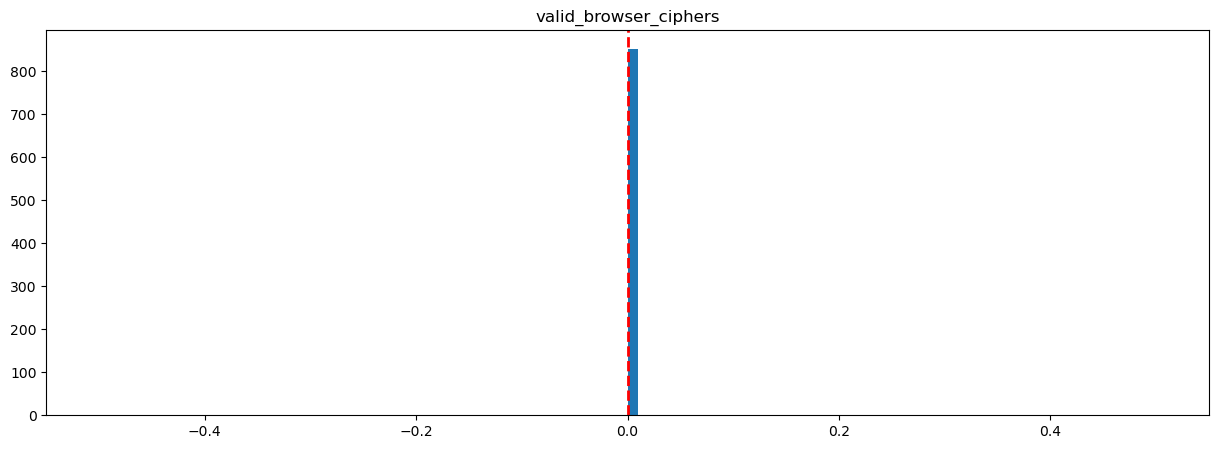

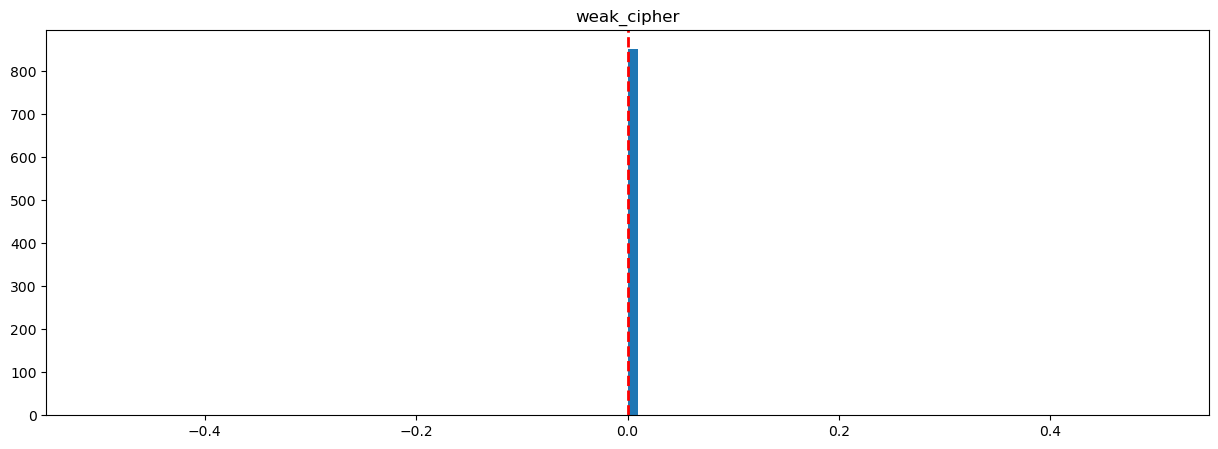

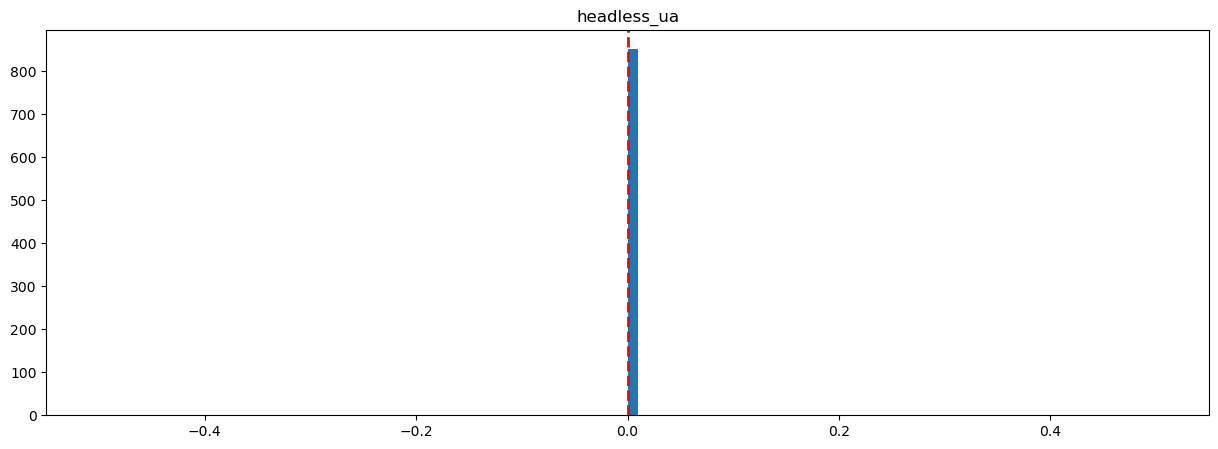

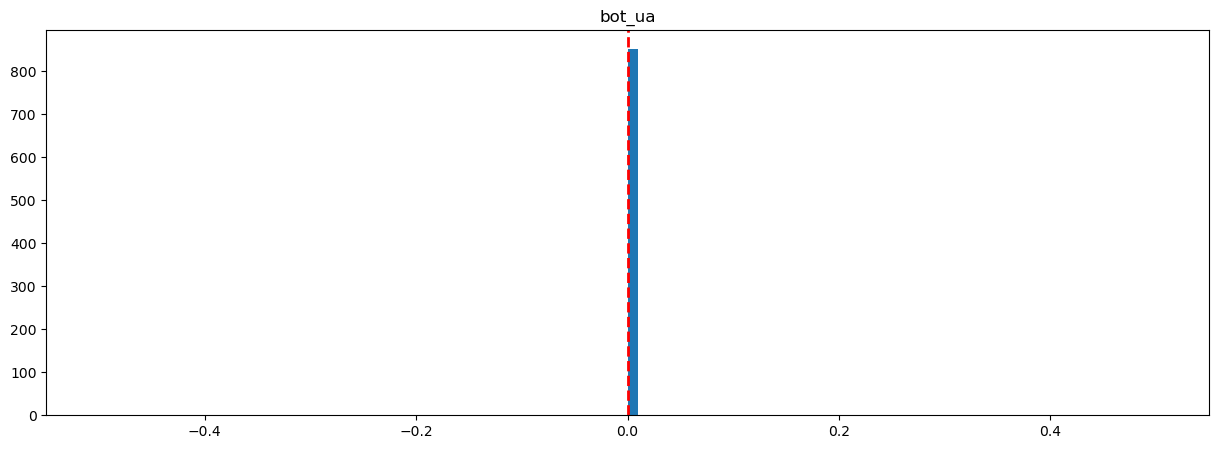

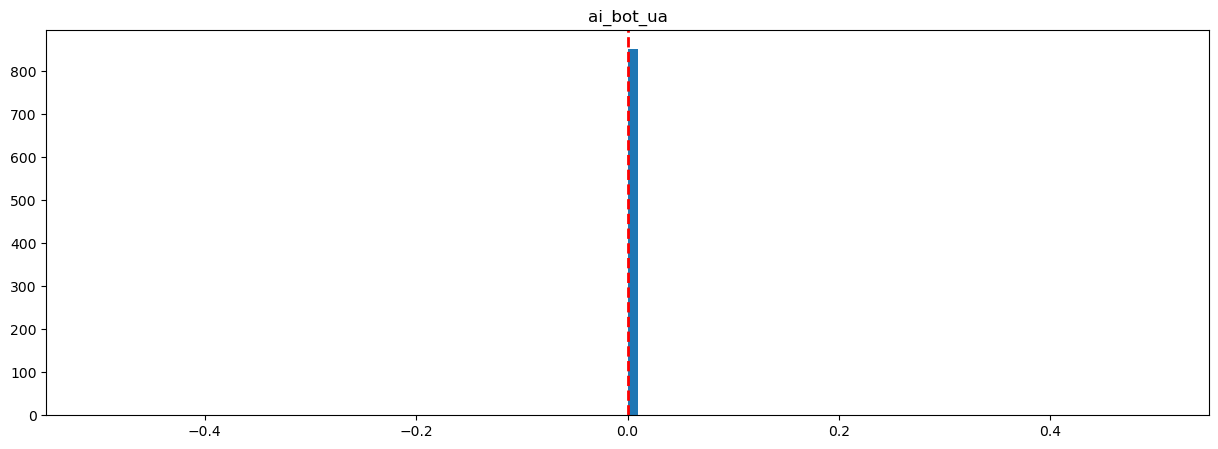

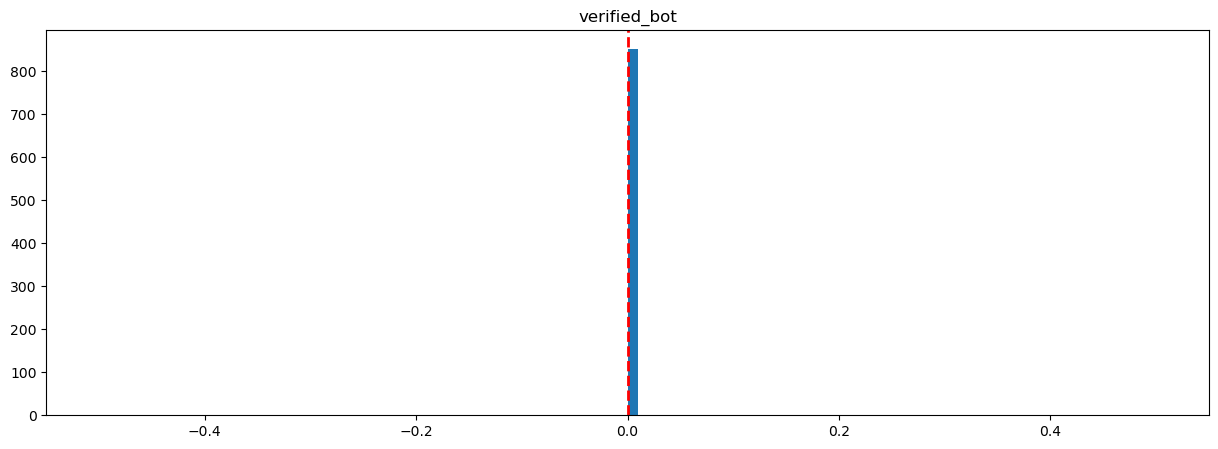

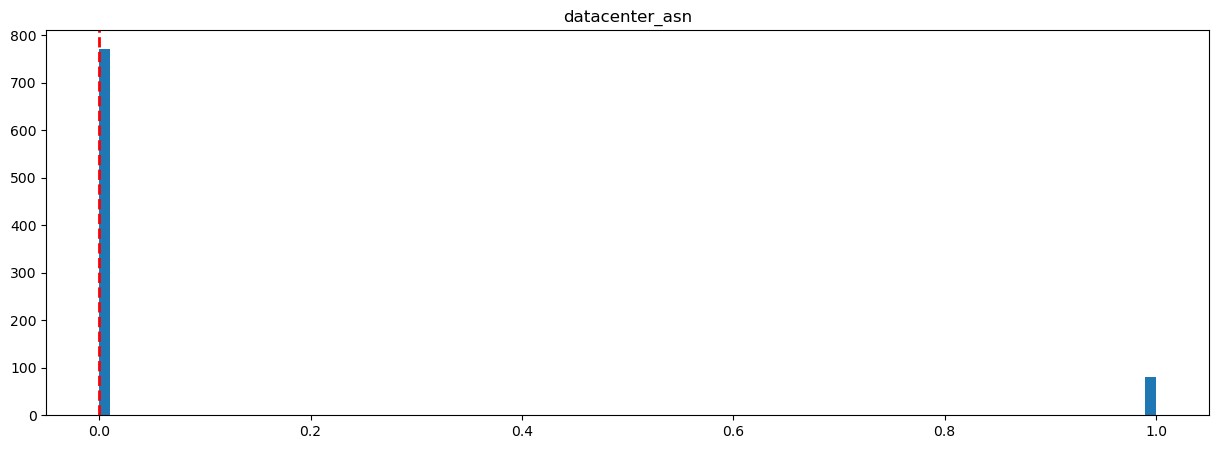

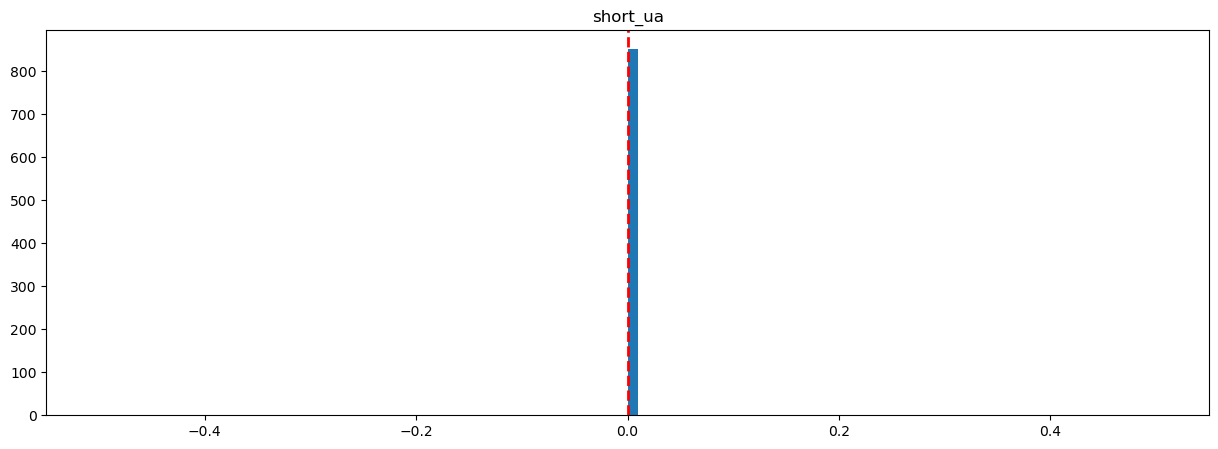

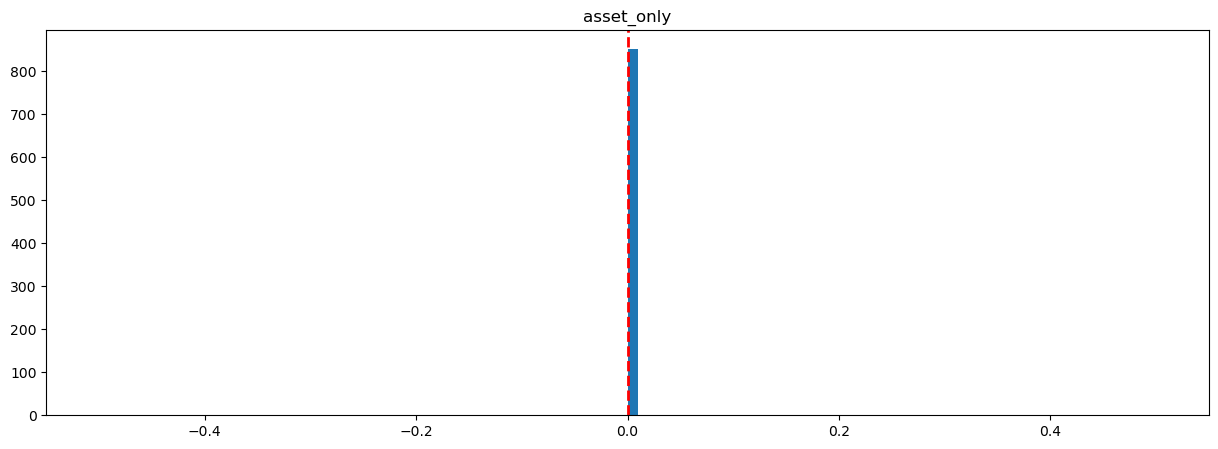

In [96]:
ss = []
for s in sessions:
    ss.append(s.get('cipher','xx'))
ss = set(ss)
print(ss)

{'TLS_CHACHA20_POLY1305_SHA256', 'TLS_AES_256_GCM_SHA384', 'TLS_AES_128_GCM_SHA256'}


In [61]:
sessions[-1]['ciphers']

['TLS_AES_128_GCM_SHA256',
 'TLS_AES_128_GCM_SHA256',
 'TLS_AES_128_GCM_SHA256',
 'TLS_AES_128_GCM_SHA256',
 'TLS_AES_256_GCM_SHA384',
 'TLS_CHACHA20_POLY1305_SHA256']

## Automated traffic

In [29]:
sessions2 = read_sessions(host, 1000, model_type=ModelType.BOT)
print('Done.')

Reading from kafka. Host = verafiles.org ... partition = 1
First session start = 2025-03-04 15:21:49 end = 2025-03-04 15:22:04
100 sessions read 2025-03-04 17:29:09 1741109351692
200 sessions read 2025-03-04 19:22:21 1741116144843
300 sessions read 2025-03-04 21:42:50 1741124572989
400 sessions read 2025-03-05 00:19:10 1741133953422
500 sessions read 2025-03-05 02:46:09 1741142770614
600 sessions read 2025-03-05 04:51:48 1741150310056
700 sessions read 2025-03-05 08:25:18 1741163120915
800 sessions read 2025-03-05 10:21:56 1741170119043
900 sessions read 2025-03-05 12:44:29 1741178672539
1.9938500006993611 minutes. Topic offset is too close to the current times...
Done.


In [30]:
scores2, shapley2 = model.transform(sessions2)

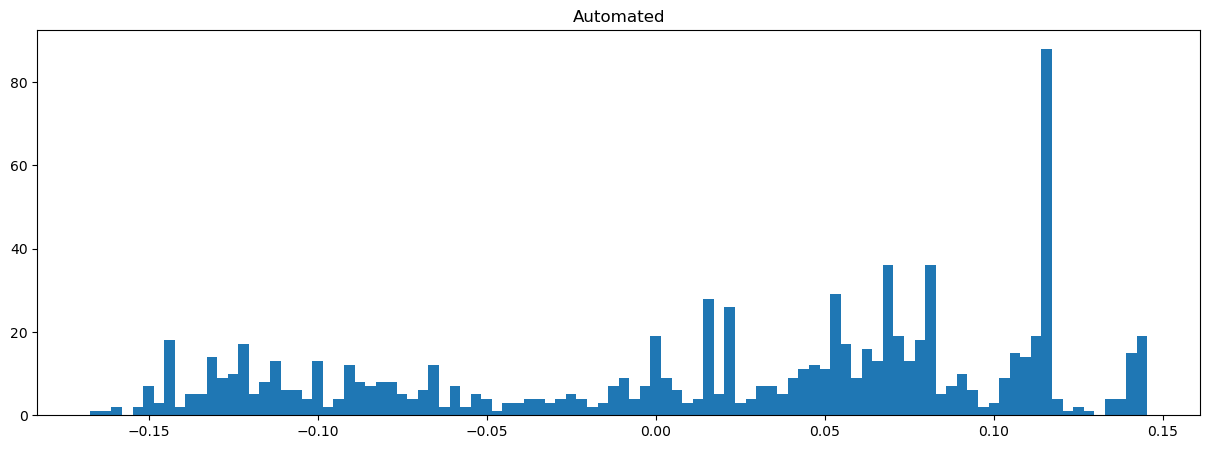

In [31]:
a = np.hstack(scores2)
_ = plt.hist(a, bins=100)  
plt.title('Automated')
plt.show()

In [32]:
print(f'Challenge rate = {challenge_rate(scores2)}')

Challenge rate = 0.34720700985761227


## Session modification

In [138]:
session2 = deepcopy(sessions[3])
session2['requests'] += sessions[10]['requests']
session2['requests'] += sessions[20]['requests']
session2['country'] = 'CA'

print('Isolation Forest')
ts = datetime.now()
score = model.transform([session2])[0]
print(f'timer = {(datetime.now()-ts).total_seconds()}')
print(f'hits={len(session["requests"])}')
print(f'Score = {score}')

Isolation Forest
timer = 0.085669
hits=2
Score = 0.05635794507072106


In [127]:
session2['country']

'UA'